<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_9a_JANA_TwoMoons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 9a — exact JANA Two Moons and topology-matched hybrid CE

This notebook answers a deliberately narrow question: **if JANA is trained on the exact main-paper Two Moons problem with the exact published BayesFlow architecture and training campaign, what changes when we retain the same flow topology but add our CE correction?**

There are two important controls.

1. Figure 4 of the JANA paper uses the **Wiqvist et al. simulator**, whose moons have radius \(1.0\) and radial noise \(0.1\). `Exercise_9b_SBIBM_TwoMoons.ipynb` uses the Lueckmann/SBIBM simulator, whose moons have radius \(0.1\) and radial noise \(0.01\). The JANA paper treats that second simulator only in its appendix. They are related benchmarks, but they are not the same numerical problem.
2. The published comparison uses legacy BayesFlow, not our 10-layer `nflows` RQS. This notebook runs the historical JANA environment in an isolated Python 3.11 process, leaving the current Colab kernel untouched for the PyTorch classifier.

The experiment produces three frozen density systems:

- **Original JANA:** posterior and likelihood flows trained jointly with the summed NLL, exactly as in the paper code.
- **Matched separate flows:** the same posterior and likelihood topologies, data, epochs, batch size, optimizer, and learning-rate schedule, but optimized through separate trainer instances.
- **Hybrid + CE:** the matched separate flows multiplied by the equal-prior \(S/P\) and \(S/L\) corrections from the same plain CE classifier architecture used in `Exercise_9b_SBIBM_TwoMoons.ipynb`.

No normalization or bridge term enters classifier training. Those identities are evaluated only after all CE checkpoints are frozen.


In [1]:
# Campaign controls
PROFILE = "PAPER"       # PAPER | SMOKE
SEED = 1                # repetition #1 shown in the JANA main paper
SIMULATION_BUDGET = 10_000 if PROFILE == "PAPER" else 512
FORCE_LEGACY_FLOWS = False
LOAD_CLASSIFIERS_IF_AVAILABLE = True

if PROFILE == "PAPER":
    POSTERIOR_PROPOSALS = 150_000
    PRIOR_PROPOSALS = 150_000
    POSTERIOR_SAMPLES = 10_000
    ANALYTIC_SAMPLES = 10_000
    CLASSIFIER_MEMBERS = 10
    CLASSIFIER_EPOCHS = 250
    CLASSIFIER_WIDTH = 1024
    CLASSIFIER_LAYERS = 4
else:
    POSTERIOR_PROPOSALS = 4_000
    PRIOR_PROPOSALS = 4_000
    POSTERIOR_SAMPLES = 2_000
    ANALYTIC_SAMPLES = 2_000
    CLASSIFIER_MEMBERS = 1
    CLASSIFIER_EPOCHS = 3
    CLASSIFIER_WIDTH = 128
    CLASSIFIER_LAYERS = 2

if PROFILE == "PAPER" and SIMULATION_BUDGET != 10_000:
    raise ValueError("The paper campaign requires exactly 10,000 simulations.")


In [2]:
# Colab setup: repository, persistent artifacts, and isolated JANA environment.
import hashlib
import json
import os
import shutil
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
IN_COLAB = "google.colab" in sys.modules

def run(*args, env=None):
    command = [str(arg) for arg in args]
    print("+", " ".join(command))
    subprocess.run(command, check=True, env=env)

if IN_COLAB:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

    REPO_DIR = Path("/content/nsbi-lhc-toolkit")
    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)
    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    ARTIFACT_ROOT = Path(
        f"/content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_{SEED:02d}"
    )
    LEGACY_ENV = Path("/content/jana-paper-py311")
else:
    candidates = [
        Path.cwd(),
        Path.cwd() / "workshops" / "ml4hep_tifr_colab",
    ]
    TUTORIAL_DIR = next(
        path for path in candidates
        if (path / "jana_twomoons_paper_driver.py").is_file()
    )
    ARTIFACT_ROOT = (
        Path.cwd() / "exercise_9a_JANA_TwoMoons_artifacts" / f"seed_{SEED:02d}"
    )
    LEGACY_ENV = Path("/tmp/jana-paper-py311")

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
DRIVER = TUTORIAL_DIR / "jana_twomoons_paper_driver.py"
REQUIREMENTS = TUTORIAL_DIR / "requirements_jana_twomoons_paper.txt"
for required in (DRIVER, REQUIREMENTS):
    if not required.is_file():
        raise FileNotFoundError(required)

if shutil.which("uv") is None:
    run(sys.executable, "-m", "pip", "install", "-q", "uv")
UV = shutil.which("uv") or str(Path(sys.executable).parent / "uv")
UV_ENV = os.environ.copy()
UV_ENV.setdefault("UV_CACHE_DIR", str(LEGACY_ENV.parent / "jana-uv-cache"))
UV_ENV.setdefault("UV_PYTHON_INSTALL_DIR", str(LEGACY_ENV.parent / "jana-uv-python"))
LEGACY_PYTHON = LEGACY_ENV / "bin" / "python"
if not LEGACY_PYTHON.is_file():
    run(UV, "venv", "--python", "3.11", LEGACY_ENV, env=UV_ENV)

requirements_digest = hashlib.sha256(REQUIREMENTS.read_bytes()).hexdigest()
stamp = LEGACY_ENV / ".jana_requirements_sha256"
if not stamp.is_file() or stamp.read_text().strip() != requirements_digest:
    run(
        UV, "pip", "install", "--python", LEGACY_PYTHON,
        "--requirement", REQUIREMENTS,
        env=UV_ENV,
    )
    # JAX is not imported by this experiment. The 2023 requirements did not
    # pin jaxlib, so a 2026 resolver pairs jax 0.4.10 with an incompatible
    # modern jaxlib. Removing both restores TensorFlow import without changing
    # any JANA model, loss, optimizer, simulator, or numerical dependency.
    run(
        UV, "pip", "uninstall", "--python", LEGACY_PYTHON,
        "jax", "jaxlib", env=UV_ENV,
    )
    stamp.write_text(requirements_digest)

if str(TUTORIAL_DIR) not in sys.path:
    sys.path.insert(0, str(TUTORIAL_DIR))
print("Tutorial directory:", TUTORIAL_DIR)
print("Persistent artifact root:", ARTIFACT_ROOT)
print("Legacy JANA Python:", LEGACY_PYTHON)


Mounted at /content/drive
+ git clone --depth 1 --filter=blob:none --sparse --branch ml4hep_school_tutorial https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git /content/nsbi-lhc-toolkit
+ git -C /content/nsbi-lhc-toolkit sparse-checkout set src workshops/ml4hep_tifr_colab
+ /usr/local/bin/uv venv --python 3.11 /content/jana-paper-py311
+ /usr/local/bin/uv pip install --python /content/jana-paper-py311/bin/python --requirement /content/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab/requirements_jana_twomoons_paper.txt
+ /usr/local/bin/uv pip uninstall --python /content/jana-paper-py311/bin/python jax jaxlib
Tutorial directory: /content/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab
Persistent artifact root: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01
Legacy JANA Python: /content/jana-paper-py311/bin/python


## 1. Exact architecture and optimization contract

The following settings are not inferred from the paper's plots. They are read from `experiments/two_moons/jana.py` at JANA-Paper commit `6cbbc94...` and from BayesFlow commit `153dfef...`.

| Component | Published setting used here |
|---|---|
| Prior | \(\theta\sim\mathcal U([-2,2]^2)\) |
| Observation | \(x_{\rm obs}=(0,0)\) |
| Simulator | Wiqvist main-paper Two Moons |
| Posterior flow | 4 spline coupling layers |
| Likelihood flow | 5 interleaved layers: affine/spline/affine/spline/affine |
| Permutation | Learned orthogonal transform |
| Spline subnet regularization | L2 coefficient \(5\times10^{-3}\), dropout 0.05 |
| Affine subnet regularization | L2 coefficient \(5\times10^{-4}\), dropout 0.01 |
| Within-coupling subnet | 2 dense layers × 128 ReLU units |
| Spline | 16 bins over \([-5,5]\) |
| ActNorm | Enabled |
| Training | 64 epochs, batch size 32 |
| Optimizer | Adam, initial LR \(5\times10^{-4}\), cosine decay to zero |
| Gradient clipping | Global norm 1 |
| Validation | 300 extra monitoring simulations; no early stopping |
| Main budget | 10,000 training simulations |

The original script does not seed TensorFlow. This reproduction adds a TensorFlow seed so that a saved run can be reused; it does not alter the model, loss, optimizer, or data distribution. The original requirements also left `jaxlib` unpinned. Since JAX is unused here and modern resolvers select a `jaxlib` incompatible with the paper's `jax==0.4.10`, the setup removes both JAX packages after installing every published pin. TensorFlow, TensorFlow Probability, BayesFlow, NumPy, and all training-relevant versions remain exactly pinned.


In [3]:
# Train or reuse the exact legacy flows.
command = [
    str(LEGACY_PYTHON),
    str(DRIVER),
    "--artifact-root", str(ARTIFACT_ROOT),
    "--simulation-budget", str(SIMULATION_BUDGET),
    "--seed", str(SEED),
    "--posterior-proposals", str(POSTERIOR_PROPOSALS),
    "--prior-proposals", str(PRIOR_PROPOSALS),
    "--posterior-samples", str(POSTERIOR_SAMPLES),
    "--analytic-samples", str(ANALYTIC_SAMPLES),
]
if FORCE_LEGACY_FLOWS:
    command.append("--force")
run(*command)


+ /content/jana-paper-py311/bin/python /content/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab/jana_twomoons_paper_driver.py --artifact-root /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01 --simulation-budget 10000 --seed 1 --posterior-proposals 150000 --prior-proposals 150000 --posterior-samples 10000 --analytic-samples 10000


In [4]:
# Load and validate immutable outputs from the pinned environment.
import numpy as np
import pandas as pd
from IPython.display import display

metadata_path = ARTIFACT_ROOT / "legacy_flow_metadata.json"
arrays_path = ARTIFACT_ROOT / "legacy_flow_outputs.npz"
metadata = json.loads(metadata_path.read_text())
legacy = dict(np.load(arrays_path, allow_pickle=False))

expected = {
    "seed": SEED,
    "simulation_budget": SIMULATION_BUDGET,
    "posterior_proposals": POSTERIOR_PROPOSALS,
    "prior_proposals": PRIOR_PROPOSALS,
    "posterior_samples": POSTERIOR_SAMPLES,
    "jana_paper_commit": "6cbbc94faf0aa85147986f7f9516d13a52551bd4",
    "bayesflow_commit": "153dfefadd347717b7aeb9c4872a4b51ac04e83c",
    "simulator": "Wiqvist_et_al_main_paper_two_moons",
}
mismatches = {
    key: (metadata.get(key), value)
    for key, value in expected.items()
    if metadata.get(key) != value
}
if mismatches:
    raise RuntimeError(f"Incompatible legacy artifacts: {mismatches}")
for name, values in legacy.items():
    if not np.isfinite(values).all():
        raise FloatingPointError(f"Non-finite legacy array {name}")
print(json.dumps({key: metadata[key] for key in expected}, indent=2))
display(pd.DataFrame(
    [{"array": name, "shape": str(values.shape), "dtype": str(values.dtype)}
     for name, values in legacy.items()]
))


{
  "seed": 1,
  "simulation_budget": 10000,
  "posterior_proposals": 150000,
  "prior_proposals": 150000,
  "posterior_samples": 10000,
  "jana_paper_commit": "6cbbc94faf0aa85147986f7f9516d13a52551bd4",
  "bayesflow_commit": "153dfefadd347717b7aeb9c4872a4b51ac04e83c",
  "simulator": "Wiqvist_et_al_main_paper_two_moons"
}


,array,shape,dtype
0,theta_train,"(10000, 2)",float32
1,x_train,"(10000, 2)",float32
2,theta_p,"(10000, 2)",float32
3,x_l,"(10000, 2)",float32
4,joint_posterior_samples,"(10000, 2)",float32
5,separate_posterior_proposals,"(150000, 2)",float32
6,prior_theta,"(150000, 2)",float32
7,joint_log_likelihood,"(150000,)",float64
8,separate_log_likelihood,"(150000,)",float64
9,joint_log_posterior,"(150000,)",float64


## 2. Equal-prior CE correction

Let \(S\), \(P\), and \(L\) denote the three joint laws

\[
S(\theta,x)=p(\theta,x),\qquad
P(\theta,x)=p(x)\,q_\phi(\theta\mid x),\qquad
L(\theta,x)=p(\theta)\,q_\eta(x\mid\theta).
\]

The simulator rows used to train the flows form \(S\). We obtain one frozen-flow draw per matching context for \(P\) and \(L\), preserving triplets during the classifier split. A plain three-class network is trained only with

\[
\mathcal L_{\rm CE}=-\mathbb E\log D_Y(\theta,x).
\]

With equal class priors,

\[
r_P(\theta,x)=\frac{S}{P}=\frac{D_S}{D_P},\qquad
r_L(\theta,x)=\frac{S}{L}=\frac{D_S}{D_L}.
\]

As in the current Exercise 9b, classifier inputs receive one fixed training-column mean/standard-deviation change of units. There is no learned normalization layer, dropout, weight decay, residual block, density feature, normalization loss, or bridge loss.


In [5]:
# Construct complete S/P/L triplets and one leakage-free classifier split.
theta = legacy["theta_train"].astype(np.float32)
x = legacy["x_train"].astype(np.float32)
theta_p = legacy["theta_p"].astype(np.float32)
x_l = legacy["x_l"].astype(np.float32)

S = np.column_stack([theta, x])
P = np.column_stack([theta_p, x])
L = np.column_stack([theta, x_l])
groups = np.stack([S, P, L], axis=1).astype(np.float32)
if groups.shape != (SIMULATION_BUDGET, 3, 4):
    raise RuntimeError(f"Unexpected grouped classifier shape {groups.shape}")

split_rng = np.random.default_rng(SEED + 10_001)
permutation = split_rng.permutation(len(groups))
n_train = int(0.8 * len(groups))
train_index, validation_index = permutation[:n_train], permutation[n_train:]
if np.intersect1d(train_index, validation_index).size:
    raise RuntimeError("Classifier train/validation leakage")
train_groups_raw = groups[train_index]
validation_groups_raw = groups[validation_index]

flat_train = train_groups_raw.reshape(-1, train_groups_raw.shape[-1])
classifier_center = flat_train.mean(axis=0, dtype=np.float64).astype(np.float32)
classifier_scale = flat_train.std(axis=0, dtype=np.float64).astype(np.float32)
classifier_scale = np.where(classifier_scale > 1e-6, classifier_scale, 1.0).astype(np.float32)

def transform_classifier_points(values):
    values = np.asarray(values, dtype=np.float32)
    return ((values - classifier_center) / classifier_scale).astype(np.float32)

train_groups = transform_classifier_points(train_groups_raw)
validation_groups = transform_classifier_points(validation_groups_raw)
print("Classifier groups:", len(train_groups), "train +", len(validation_groups), "validation")
print("Fixed center:", classifier_center)
print("Fixed scale:", classifier_scale)


Classifier groups: 8000 train + 2000 validation
Fixed center: [ 0.01003091  0.01870854  0.6992637  -0.02381339]
Fixed scale: [1.1435084  1.1602817  0.74268943 1.3445563 ]


In [6]:
# Train or load the exact Exercise-9b CE-only classifier topology.
import copy
import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from utils_exercise9b_contract import (
    INITIAL_LEARNING_RATE,
    LEARNING_RATE_DROP_FACTOR,
    LEARNING_RATE_STEP_EPOCHS,
    MINIMUM_LEARNING_RATE,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_S, CLASS_P, CLASS_L = 0, 1, 2
CLASSIFIER_ROW_BATCH_BUDGET = 32
classifier_checkpoint_dir = ARTIFACT_ROOT / "plain_three_class_classifier"
classifier_checkpoint_dir.mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    random.seed(int(seed))
    np.random.seed(int(seed) % (2**32))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

class PlainThreeClassMLP(nn.Module):
    def __init__(self, input_dim, width, hidden_layers):
        super().__init__()
        layers = []
        n_input = int(input_dim)
        for _ in range(int(hidden_layers)):
            layers.extend([nn.Linear(n_input, int(width)), nn.ReLU()])
            n_input = int(width)
        layers.append(nn.Linear(n_input, 3))
        self.network = nn.Sequential(*layers)

    def forward(self, values):
        return self.network(values)

def scheduled_learning_rate(epoch):
    return max(
        MINIMUM_LEARNING_RATE,
        INITIAL_LEARNING_RATE
        * LEARNING_RATE_DROP_FACTOR ** (int(epoch) // LEARNING_RATE_STEP_EPOCHS),
    )

def set_learning_rate(optimizer, epoch):
    value = scheduled_learning_rate(epoch)
    for group in optimizer.param_groups:
        group["lr"] = value
    return value

def class_ce(model, group_batch):
    group_batch = group_batch.to(device)
    logits = model(group_batch.reshape(-1, group_batch.shape[-1]))
    labels = torch.arange(3, device=device).repeat(len(group_batch))
    return F.cross_entropy(logits, labels)

@torch.no_grad()
def validation_ce(model, values, chunk_size=512):
    model.eval()
    total = 0.0
    for start in range(0, len(values), int(chunk_size)):
        batch = values[start:start + int(chunk_size)]
        total += float(class_ce(model, batch).cpu()) * len(batch)
    return total / len(values)

classifier_config = {
    "input_dim": 4,
    "width": CLASSIFIER_WIDTH,
    "hidden_layers": CLASSIFIER_LAYERS,
    "members": CLASSIFIER_MEMBERS,
    "epochs": CLASSIFIER_EPOCHS,
    "batch_size_row_budget": CLASSIFIER_ROW_BATCH_BUDGET,
    "initial_learning_rate": INITIAL_LEARNING_RATE,
    "minimum_learning_rate": MINIMUM_LEARNING_RATE,
    "learning_rate_drop_factor": LEARNING_RATE_DROP_FACTOR,
    "learning_rate_step_epochs": LEARNING_RATE_STEP_EPOCHS,
    "objective": "equal_prior_multiclass_ce_only",
    "input_transform": "fixed_training_column_mean_std_v1",
    "regularization": "none",
    "seed": SEED,
    "simulation_budget": SIMULATION_BUDGET,
    "flow_artifact_metadata": hashlib.sha256(metadata_path.read_bytes()).hexdigest(),
}

def checkpoint_path(member):
    return classifier_checkpoint_dir / f"member_{member:02d}.pt"

def load_classifier_ensemble():
    if not LOAD_CLASSIFIERS_IF_AVAILABLE:
        return None
    if not all(checkpoint_path(member).is_file() for member in range(CLASSIFIER_MEMBERS)):
        return None
    loaded = []
    for member in range(CLASSIFIER_MEMBERS):
        try:
            saved = torch.load(
                checkpoint_path(member), map_location=device, weights_only=False
            )
        except TypeError:
            saved = torch.load(checkpoint_path(member), map_location=device)
        if saved.get("config") != {**classifier_config, "member": member}:
            raise RuntimeError(f"Incompatible classifier checkpoint {checkpoint_path(member)}")
        if not np.array_equal(np.asarray(saved["center"]), classifier_center):
            raise RuntimeError("Classifier center mismatch")
        if not np.array_equal(np.asarray(saved["scale"]), classifier_scale):
            raise RuntimeError("Classifier scale mismatch")
        model = PlainThreeClassMLP(
            classifier_config["input_dim"],
            classifier_config["width"],
            classifier_config["hidden_layers"],
        ).to(device)
        model.load_state_dict(saved["state_dict"], strict=True)
        model.eval()
        loaded.append({"model": model, "history": saved["history"]})
    print("Loaded", len(loaded), "frozen CE members")
    return loaded

def train_classifier_ensemble():
    train_tensor = torch.as_tensor(train_groups, dtype=torch.float32)
    validation_tensor = torch.as_tensor(validation_groups, dtype=torch.float32)
    trained = []
    for member in range(CLASSIFIER_MEMBERS):
        member_seed = SEED + 20_003 + 10_007 * member
        seed_everything(member_seed)
        model = PlainThreeClassMLP(
            classifier_config["input_dim"],
            classifier_config["width"],
            classifier_config["hidden_layers"],
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=INITIAL_LEARNING_RATE)
        loader_generator = torch.Generator().manual_seed(member_seed + 1)
        loader = DataLoader(
            TensorDataset(train_tensor),
            batch_size=max(1, CLASSIFIER_ROW_BATCH_BUDGET // 3),
            shuffle=True,
            generator=loader_generator,
        )
        history = {"train_ce": [], "validation_ce": [], "learning_rate": []}
        best_state, best_value, stale = None, math.inf, 0
        for epoch in range(CLASSIFIER_EPOCHS):
            learning_rate = set_learning_rate(optimizer, epoch)
            model.train()
            running, rows = 0.0, 0
            for (group_batch,) in loader:
                optimizer.zero_grad(set_to_none=True)
                ce = class_ce(model, group_batch)
                if not bool(torch.isfinite(ce)):
                    raise FloatingPointError("Non-finite classifier CE")
                ce.backward()
                optimizer.step()
                running += float(ce.detach().cpu()) * len(group_batch)
                rows += len(group_batch)
            heldout = validation_ce(model, validation_tensor)
            history["train_ce"].append(running / rows)
            history["validation_ce"].append(heldout)
            history["learning_rate"].append(learning_rate)
            if heldout < best_value - 1e-6:
                best_value = heldout
                best_state = copy.deepcopy(model.state_dict())
                stale = 0
            else:
                stale += 1
            if (
                epoch == 0
                or (epoch + 1) % LEARNING_RATE_STEP_EPOCHS == 0
                or epoch + 1 == CLASSIFIER_EPOCHS
            ):
                print(
                    f"member {member + 1}/{CLASSIFIER_MEMBERS}, "
                    f"epoch {epoch + 1:03d}: CE={history['train_ce'][-1]:.5f}, "
                    f"val={heldout:.5f}, lr={learning_rate:.1e}"
                )
            if stale >= CLASSIFIER_EPOCHS:
                break
        if best_state is None:
            raise RuntimeError("Classifier training produced no finite checkpoint")
        model.load_state_dict(best_state)
        model.eval()
        payload = {
            "state_dict": best_state,
            "config": {**classifier_config, "member": member},
            "center": classifier_center,
            "scale": classifier_scale,
            "history": history,
        }
        torch.save(payload, checkpoint_path(member))
        trained.append({"model": model, "history": history})
    return trained

classifier = load_classifier_ensemble()
if classifier is None:
    classifier = train_classifier_ensemble()
print("Classifier device:", device)
print("Parameters/member:", sum(
    parameter.numel() for parameter in classifier[0]["model"].parameters()
))


Loaded 10 frozen CE members
Classifier device: cuda
Parameters/member: 3156995


## 3. Freeze first, diagnose second

The deployed ratio is the arithmetic mean of the **member-wise positive softmax quotients**. We do not average logits, exponentiate a learned log ratio, or tune a checkpoint with the checks below.

Two checks are especially informative:

- \(E_{q_\phi(\theta\mid x)}[r_P(\theta,x)]=1\) and \(E_{q_\eta(x\mid\theta)}[r_L(\theta,x)]=1\);
- the posterior and likelihood routes should satisfy, up to the evidence constant,
  \[
  \log p(\theta)+\log q_\eta(x\mid\theta)+\log r_L
  -\log q_\phi(\theta\mid x)-\log r_P=\log p(x).
  \]

The bridge standard deviation therefore measures *route disagreement*, not posterior accuracy by itself.


In [7]:
# Frozen CE inference and post-training audits.
@torch.no_grad()
def predict_ratios(points, batch_size=16_384):
    points = np.asarray(points, dtype=np.float32)
    posterior_chunks, likelihood_chunks = [], []
    tiny = torch.finfo(torch.float64).tiny
    for start in range(0, len(points), int(batch_size)):
        stop = min(len(points), start + int(batch_size))
        standardized = transform_classifier_points(points[start:stop])
        tensor = torch.as_tensor(standardized, device=device)
        posterior_mean = None
        likelihood_mean = None
        for pack in classifier:
            probabilities = torch.softmax(
                pack["model"](tensor).to(torch.float64), dim=1
            )
            r_p = (
                probabilities[:, CLASS_S]
                / probabilities[:, CLASS_P].clamp_min(tiny)
            )
            r_l = (
                probabilities[:, CLASS_S]
                / probabilities[:, CLASS_L].clamp_min(tiny)
            )
            scale = float(len(classifier))
            posterior_mean = (
                r_p / scale if posterior_mean is None
                else posterior_mean + r_p / scale
            )
            likelihood_mean = (
                r_l / scale if likelihood_mean is None
                else likelihood_mean + r_l / scale
            )
        posterior_chunks.append(posterior_mean.cpu().numpy())
        likelihood_chunks.append(likelihood_mean.cpu().numpy())
    result = np.column_stack([
        np.concatenate(posterior_chunks),
        np.concatenate(likelihood_chunks),
    ])
    if not np.isfinite(result).all() or np.any(result <= 0.0):
        raise FloatingPointError("Invalid deployed CE probability quotient")
    return result

validation_tensor = torch.as_tensor(validation_groups, dtype=torch.float32)
member_validation_ce = [
    validation_ce(pack["model"], validation_tensor) for pack in classifier
]

audit_p_points = legacy["audit_posterior_points"]
audit_l_points = legacy["audit_likelihood_points"]
audit_p_group = legacy["audit_posterior_group"].astype(int)
audit_l_group = legacy["audit_likelihood_group"].astype(int)
r_p_audit = predict_ratios(audit_p_points)[:, 0]
r_l_audit = predict_ratios(audit_l_points)[:, 1]

def grouped_means(values, group_ids):
    n_groups = int(group_ids.max()) + 1
    sums = np.bincount(group_ids, weights=values, minlength=n_groups)
    counts = np.bincount(group_ids, minlength=n_groups)
    return sums / counts

z_p = grouped_means(r_p_audit, audit_p_group)
z_l = grouped_means(r_l_audit, audit_l_group)

prior_theta = legacy["prior_theta"].astype(np.float32)
observation_rows = np.zeros_like(prior_theta)
prior_points = np.column_stack([prior_theta, observation_rows])
prior_ratios = predict_ratios(prior_points)
log_prior = -np.log(16.0)
pure_bridge = (
    log_prior
    + legacy["joint_log_likelihood"]
    - legacy["joint_log_posterior"]
)
separate_bridge = (
    log_prior
    + legacy["separate_log_likelihood"]
    - legacy["separate_log_posterior"]
)
corrected_bridge = (
    separate_bridge
    + np.log(prior_ratios[:, 1])
    - np.log(prior_ratios[:, 0])
)

diagnostics = pd.DataFrame([
    {
        "quantity": "held-out CE (member mean)",
        "value": float(np.mean(member_validation_ce)),
    },
    {
        "quantity": "RMS log E_qphi[r_P]",
        "value": float(np.sqrt(np.mean(np.log(z_p) ** 2))),
    },
    {
        "quantity": "RMS log E_qeta[r_L]",
        "value": float(np.sqrt(np.mean(np.log(z_l) ** 2))),
    },
    {
        "quantity": "bridge std: original joint JANA",
        "value": float(np.std(pure_bridge)),
    },
    {
        "quantity": "bridge std: matched separate flows",
        "value": float(np.std(separate_bridge)),
    },
    {
        "quantity": "bridge std: matched flows + CE",
        "value": float(np.std(corrected_bridge)),
    },
])
display(diagnostics)


,quantity,value
0,held-out CE (member mean),1.091852
1,RMS log E_qphi[r_P],0.039002
2,RMS log E_qeta[r_L],0.034469
3,bridge std: original joint JANA,15.721450
4,bridge std: matched separate flows,12.644656
5,bridge std: matched flows + CE,10.746272


In [8]:
# Build posterior samples through both routes.
def normalized_positive(values):
    values = np.asarray(values, dtype=np.float64)
    if not np.isfinite(values).all() or np.any(values <= 0.0):
        raise FloatingPointError("Invalid positive weights")
    return values / values.sum(dtype=np.float64)

def normalized_from_log(log_values):
    log_values = np.asarray(log_values, dtype=np.float64)
    if not np.isfinite(log_values).all():
        raise FloatingPointError("Invalid log weights")
    shifted = log_values - np.max(log_values)
    return normalized_positive(np.exp(shifted))

def resample(values, weights, n_samples, seed):
    rng = np.random.default_rng(int(seed))
    index = rng.choice(
        len(values), size=int(n_samples), replace=True, p=weights
    )
    return np.asarray(values[index], dtype=np.float32)

def unweighted_sample(values, n_samples, seed):
    rng = np.random.default_rng(int(seed))
    index = rng.choice(
        len(values),
        size=int(n_samples),
        replace=int(n_samples) > len(values),
    )
    return np.asarray(values[index], dtype=np.float32)

N_EVALUATION = min(10_000, POSTERIOR_SAMPLES)
joint_direct = unweighted_sample(
    legacy["joint_posterior_samples"], N_EVALUATION, SEED + 30_001
)
separate_proposal = legacy["separate_posterior_proposals"].astype(np.float32)
proposal_points = np.column_stack([
    separate_proposal,
    np.zeros_like(separate_proposal),
])
proposal_r_p = predict_ratios(proposal_points)[:, 0]
hybrid_posterior_weights = normalized_positive(proposal_r_p)
separate_direct = unweighted_sample(
    separate_proposal, N_EVALUATION, SEED + 30_002
)
hybrid_posterior = resample(
    separate_proposal,
    hybrid_posterior_weights,
    N_EVALUATION,
    SEED + 30_003,
)

joint_likelihood_weights = normalized_from_log(
    legacy["joint_log_likelihood"]
)
joint_likelihood_route = resample(
    prior_theta,
    joint_likelihood_weights,
    N_EVALUATION,
    SEED + 30_004,
)
hybrid_likelihood_weights = normalized_from_log(
    legacy["separate_log_likelihood"] + np.log(prior_ratios[:, 1])
)
hybrid_likelihood = resample(
    prior_theta,
    hybrid_likelihood_weights,
    N_EVALUATION,
    SEED + 30_005,
)

def ess(weights):
    weights = np.asarray(weights, dtype=np.float64)
    return float(1.0 / np.sum(weights ** 2))

def inside_prior(values):
    values = np.asarray(values)
    return np.all((values >= -2.0) & (values <= 2.0), axis=1)

inference_diagnostics = pd.DataFrame([
    {
        "route": "hybrid posterior proposal",
        "ESS": ess(hybrid_posterior_weights),
        "ESS fraction": (
            ess(hybrid_posterior_weights) / len(hybrid_posterior_weights)
        ),
        "fraction inside prior": float(inside_prior(separate_proposal).mean()),
    },
    {
        "route": "original JANA likelihood",
        "ESS": ess(joint_likelihood_weights),
        "ESS fraction": (
            ess(joint_likelihood_weights) / len(joint_likelihood_weights)
        ),
        "fraction inside prior": 1.0,
    },
    {
        "route": "hybrid likelihood",
        "ESS": ess(hybrid_likelihood_weights),
        "ESS fraction": (
            ess(hybrid_likelihood_weights) / len(hybrid_likelihood_weights)
        ),
        "fraction inside prior": 1.0,
    },
])
display(inference_diagnostics)

result_path = ARTIFACT_ROOT / "posterior_route_samples.npz"
np.savez_compressed(
    result_path,
    analytic=legacy["analytic_reference"],
    jana_joint_posterior=joint_direct,
    matched_separate_posterior=separate_direct,
    hybrid_posterior_ce=hybrid_posterior,
    jana_joint_likelihood_route=joint_likelihood_route,
    hybrid_likelihood_ce=hybrid_likelihood,
)
print("Saved:", result_path)


,route,ESS,ESS fraction,fraction inside prior
0,hybrid posterior proposal,141448.028204,0.942987,0.999633
1,original JANA likelihood,21130.577339,0.140871,1.000000
2,hybrid likelihood,21025.141624,0.140168,1.000000


Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/posterior_route_samples.npz


## 4. Paper-matched posterior metric and visual comparison

For direct comparability, the table below uses the JANA repository's multiscale Gaussian-kernel MMD estimator and exactly 1,000 posterior points per method. This is intentionally distinct from the median-bandwidth MMD used by the broader Exercise 9b campaign.


In [9]:
# Exact multiscale Gaussian MMD used by JANA-Paper.
from scipy.spatial.distance import cdist

PAPER_SIGMAS = np.asarray([
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 5, 10, 15,
    20, 25, 30, 35, 100, 1e3, 1e4, 1e5, 1e6,
], dtype=np.float64)

def paper_kernel(distance2):
    result = np.zeros_like(distance2, dtype=np.float64)
    for sigma in PAPER_SIGMAS:
        result += np.exp(-distance2 / (2.0 * sigma))
    return result

def paper_mmd(left, right):
    left = np.asarray(left, dtype=np.float64)
    right = np.asarray(right, dtype=np.float64)
    k_xx = paper_kernel(
        cdist(left, left, metric="sqeuclidean")
    ).mean()
    k_yy = paper_kernel(
        cdist(right, right, metric="sqeuclidean")
    ).mean()
    k_xy = paper_kernel(
        cdist(left, right, metric="sqeuclidean")
    ).mean()
    return float(np.sqrt(max(0.0, k_xx + k_yy - 2.0 * k_xy)))

metric_rng = np.random.default_rng(SEED + 40_001)
reference = legacy["analytic_reference"]
reference_1000 = reference[
    metric_rng.choice(
        len(reference), size=1_000, replace=len(reference) < 1_000
    )
]
methods = {
    "Original JANA q_phi": joint_direct,
    "Matched separate q_phi": separate_direct,
    "Hybrid q_phi + CE": hybrid_posterior,
    "Original JANA q_eta route": joint_likelihood_route,
    "Hybrid q_eta + CE": hybrid_likelihood,
}
metric_rows = []
plot_samples = {"Analytical": reference_1000}
for name, values in methods.items():
    index = metric_rng.choice(
        len(values), size=1_000, replace=len(values) < 1_000
    )
    selected = values[index]
    plot_samples[name] = selected
    metric_rows.append({
        "method": name,
        "paper multiscale MMD": paper_mmd(reference_1000, selected),
    })
metric_table = pd.DataFrame(metric_rows).sort_values(
    "paper multiscale MMD"
)
display(metric_table)
metric_table.to_csv(
    ARTIFACT_ROOT / "paper_multiscale_mmd.csv", index=False
)


,method,paper multiscale MMD
0,Original JANA q_phi,0.116700
3,Original JANA q_eta route,0.117134
1,Matched separate q_phi,0.131905
2,Hybrid q_phi + CE,0.164659
4,Hybrid q_eta + CE,0.180126


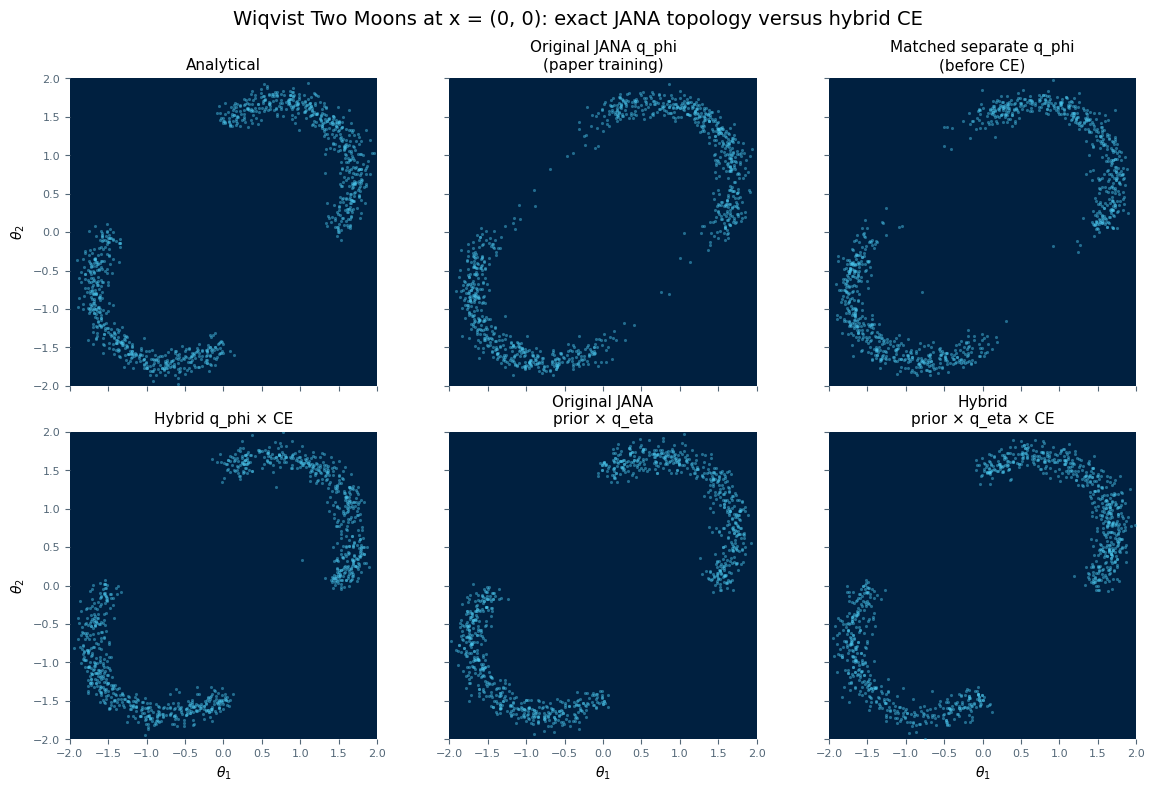

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/jana_twomoons_exact_vs_hybrid_ce.png


In [10]:
# Main comparison figure.
import matplotlib.pyplot as plt

figure, axes = plt.subplots(
    2, 3, figsize=(12, 8), sharex=True, sharey=True
)
titles = [
    "Analytical",
    "Original JANA q_phi\n(paper training)",
    "Matched separate q_phi\n(before CE)",
    "Hybrid q_phi × CE",
    "Original JANA\nprior × q_eta",
    "Hybrid\nprior × q_eta × CE",
]
keys = [
    "Analytical",
    "Original JANA q_phi",
    "Matched separate q_phi",
    "Hybrid q_phi + CE",
    "Original JANA q_eta route",
    "Hybrid q_eta + CE",
]
for axis, title, key in zip(axes.flat, titles, keys):
    values = plot_samples[key]
    axis.scatter(
        values[:, 0],
        values[:, 1],
        s=5,
        alpha=0.45,
        color="#4cc9f0",
        linewidths=0,
    )
    axis.set_title(title, fontsize=11)
    axis.set_xlim(-2, 2)
    axis.set_ylim(-2, 2)
    axis.set_aspect("equal")
    axis.set_facecolor("#002040")
    axis.grid(False)
    axis.tick_params(colors="#536777", labelsize=8)
    for spine in axis.spines.values():
        spine.set_visible(False)
for axis in axes[:, 0]:
    axis.set_ylabel(r"$\theta_2$")
for axis in axes[-1, :]:
    axis.set_xlabel(r"$\theta_1$")
figure.suptitle(
    "Wiqvist Two Moons at x = (0, 0): exact JANA topology versus hybrid CE",
    fontsize=14,
)
figure.tight_layout()
figure_path = (
    ARTIFACT_ROOT / "jana_twomoons_exact_vs_hybrid_ce.png"
)
figure.savefig(figure_path, dpi=220, bbox_inches="tight")
figure.savefig(
    ARTIFACT_ROOT / "jana_twomoons_exact_vs_hybrid_ce.pdf",
    bbox_inches="tight",
)
plt.show()
print("Saved:", figure_path)


## 5. Expanded post-training distribution diagnostics

Everything in this section is **plot-only**. It uses the analytical reference sample, the already exported frozen-flow samples and log densities, the already computed CE ratios, and the already loaded classifier checkpoints. It does not call a trainer, optimizer, simulator, or gradient calculation.

The plots retain three distinct comparisons:

1. **Original JANA (joint)** versus analytical truth tests the exact paper algorithm.
2. **Matched separate (pre-CE)** versus Original JANA isolates the optimizer partition while keeping the published flow topologies fixed.
3. **Hybrid CE** versus Matched separate isolates the effect of the frozen CE correction.

Both posterior routes are shown whenever possible: direct $q_\phi(\theta\mid x_0)$ sampling and prior-weighted $q_\eta(x_0\mid\theta)$ inference.

In [11]:
# Shared plot-only configuration and deterministic diagnostic samples.
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import ks_2samp

EXTRA_FIGURE_DIR = ARTIFACT_ROOT / "comparison_diagnostics"
EXTRA_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
EXTRA_FIGURE_PATHS = {}

def save_extra_figure(figure, key, filename):
    png_path = EXTRA_FIGURE_DIR / f"{filename}.png"
    pdf_path = EXTRA_FIGURE_DIR / f"{filename}.pdf"
    figure.savefig(png_path, dpi=200, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    EXTRA_FIGURE_PATHS[key] = {
        "png": str(png_path),
        "pdf": str(pdf_path),
    }
    plt.show()
    print("Saved:", png_path)

matched_likelihood_weights = normalized_from_log(legacy["separate_log_likelihood"])
matched_likelihood_route = resample(
    prior_theta, matched_likelihood_weights, N_EVALUATION, SEED + 50_000
)

comparison_samples = {
    "Analytical": np.asarray(legacy["analytic_reference"], dtype=np.float64),
    "Original JANA (joint)": np.asarray(joint_direct, dtype=np.float64),
    "Matched separate (pre-CE)": np.asarray(separate_direct, dtype=np.float64),
    "Hybrid CE (posterior route)": np.asarray(hybrid_posterior, dtype=np.float64),
    "Original JANA (likelihood route)": np.asarray(joint_likelihood_route, dtype=np.float64),
    "Matched separate (likelihood pre-CE)": np.asarray(matched_likelihood_route, dtype=np.float64),
    "Hybrid CE (likelihood route)": np.asarray(hybrid_likelihood, dtype=np.float64),
}
analytical_label = "Analytical"
method_labels = [label for label in comparison_samples if label != analytical_label]
comparison_colors = {
    "Analytical": "#111111",
    "Original JANA (joint)": "#0072B2",
    "Matched separate (pre-CE)": "#7A7A7A",
    "Hybrid CE (posterior route)": "#D55E00",
    "Original JANA (likelihood route)": "#56B4E9",
    "Matched separate (likelihood pre-CE)": "#009E73",
    "Hybrid CE (likelihood route)": "#CC79A7",
}
comparison_linestyles = {
    "Analytical": "-",
    "Original JANA (joint)": "-",
    "Matched separate (pre-CE)": "--",
    "Hybrid CE (posterior route)": "-",
    "Original JANA (likelihood route)": ":",
    "Matched separate (likelihood pre-CE)": "--",
    "Hybrid CE (likelihood route)": "-.",
}

diagnostic_size = min(len(values) for values in comparison_samples.values())
diagnostic_rng = np.random.default_rng(SEED + 50_001)
diagnostic_samples = {}
for label, values in comparison_samples.items():
    if len(values) == diagnostic_size:
        diagnostic_samples[label] = values.copy()
    else:
        index = diagnostic_rng.choice(len(values), size=diagnostic_size, replace=False)
        diagnostic_samples[label] = values[index]

def smoothed_histogram(values, edges, sigma=1.15):
    density, _ = np.histogram(values, bins=edges, density=True)
    density = gaussian_filter1d(density.astype(np.float64), sigma=sigma, mode="nearest")
    area = np.sum(density * np.diff(edges))
    if area > 0.0:
        density /= area
    return 0.5 * (edges[:-1] + edges[1:]), density

print("Plot-only diagnostic sample size/method:", diagnostic_size)
print("Extra figures:", EXTRA_FIGURE_DIR)

Plot-only diagnostic sample size/method: 10000
Extra figures: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics


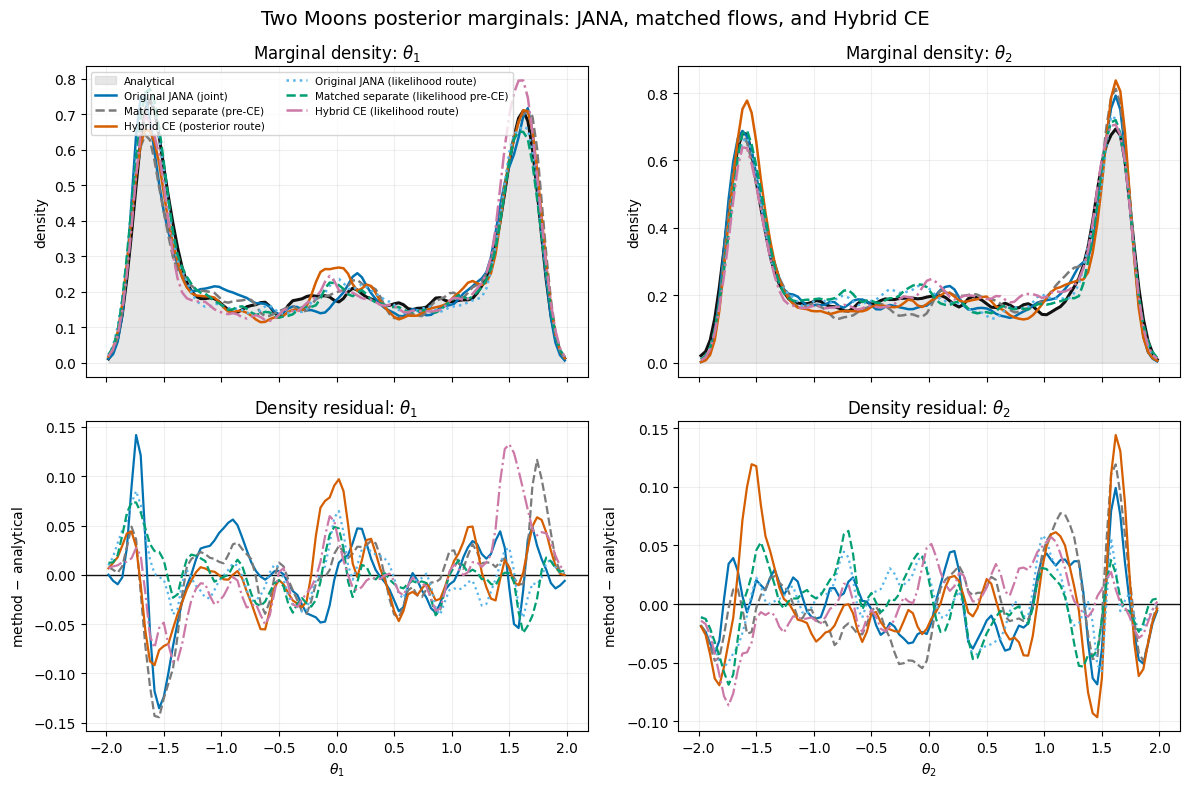

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/01_marginals_and_residuals.png


In [12]:
# Marginal densities and signed residuals relative to the analytical posterior.
marginal_edges = np.linspace(-2.0, 2.0, 101)
figure, axes = plt.subplots(2, 2, figsize=(12, 8), sharex="col")

for coordinate, symbol in enumerate((r"$\theta_1$", r"$\theta_2$")):
    centers, truth_density = smoothed_histogram(
        diagnostic_samples[analytical_label][:, coordinate], marginal_edges
    )
    axes[0, coordinate].fill_between(
        centers, truth_density, color="#BDBDBD", alpha=0.35, label="Analytical"
    )
    axes[0, coordinate].plot(centers, truth_density, color="#111111", lw=2.2)
    axes[1, coordinate].axhline(0.0, color="#111111", lw=1.0)
    for label in method_labels:
        _, density = smoothed_histogram(
            diagnostic_samples[label][:, coordinate], marginal_edges
        )
        axes[0, coordinate].plot(
            centers, density, color=comparison_colors[label],
            ls=comparison_linestyles[label], lw=1.8, label=label,
        )
        axes[1, coordinate].plot(
            centers, density - truth_density, color=comparison_colors[label],
            ls=comparison_linestyles[label], lw=1.6, label=label,
        )
    axes[0, coordinate].set(title=f"Marginal density: {symbol}", ylabel="density")
    axes[1, coordinate].set(
        title=f"Density residual: {symbol}", xlabel=symbol,
        ylabel=r"method $-$ analytical",
    )
    for axis in axes[:, coordinate]:
        axis.grid(alpha=0.2)

axes[0, 0].legend(fontsize=7.5, ncol=2)
figure.suptitle("Two Moons posterior marginals: JANA, matched flows, and Hybrid CE", fontsize=14)
figure.tight_layout()
save_extra_figure(figure, "marginals", "01_marginals_and_residuals")

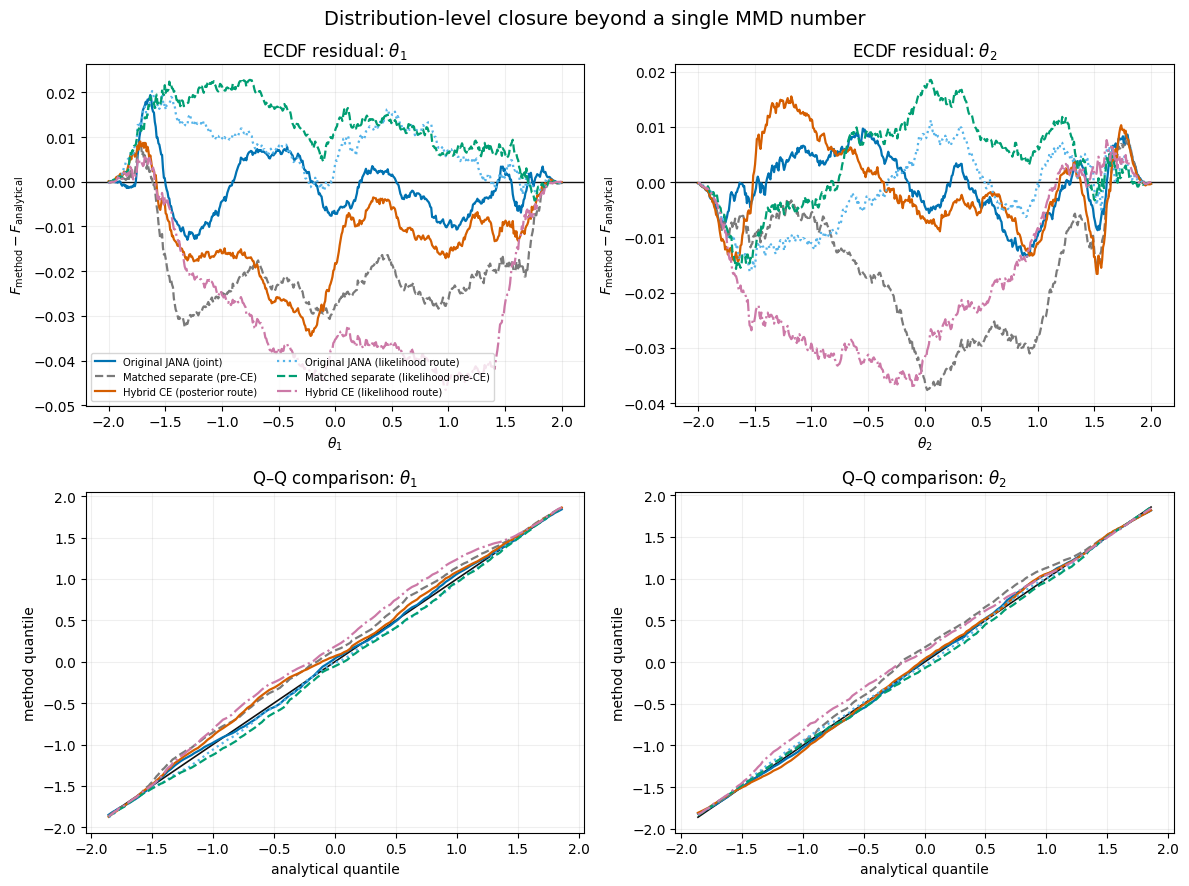

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/02_ecdf_residuals_and_qq.png


In [13]:
# ECDF residuals and quantile-quantile comparisons against analytical truth.
figure, axes = plt.subplots(2, 2, figsize=(12, 9))
ecdf_grid = np.linspace(-2.0, 2.0, 501)
probabilities = np.linspace(0.005, 0.995, 199)

for coordinate, symbol in enumerate((r"$\theta_1$", r"$\theta_2$")):
    truth_values = np.sort(diagnostic_samples[analytical_label][:, coordinate])
    truth_ecdf = np.searchsorted(truth_values, ecdf_grid, side="right") / len(truth_values)
    truth_quantiles = np.quantile(truth_values, probabilities)
    axes[0, coordinate].axhline(0.0, color="#111111", lw=1.0)
    axes[1, coordinate].plot(
        truth_quantiles, truth_quantiles, color="#111111", lw=1.2,
        label="perfect agreement",
    )
    for label in method_labels:
        values = np.sort(diagnostic_samples[label][:, coordinate])
        method_ecdf = np.searchsorted(values, ecdf_grid, side="right") / len(values)
        method_quantiles = np.quantile(values, probabilities)
        axes[0, coordinate].plot(
            ecdf_grid, method_ecdf - truth_ecdf,
            color=comparison_colors[label], ls=comparison_linestyles[label],
            lw=1.6, label=label,
        )
        axes[1, coordinate].plot(
            truth_quantiles, method_quantiles,
            color=comparison_colors[label], ls=comparison_linestyles[label],
            lw=1.6, label=label,
        )
    axes[0, coordinate].set(
        title=f"ECDF residual: {symbol}", xlabel=symbol,
        ylabel=r"$F_{\rm method}-F_{\rm analytical}$",
    )
    axes[1, coordinate].set(
        title=f"Q–Q comparison: {symbol}",
        xlabel="analytical quantile", ylabel="method quantile",
    )
    for axis in axes[:, coordinate]:
        axis.grid(alpha=0.2)

axes[0, 0].legend(fontsize=7.2, ncol=2)
figure.suptitle("Distribution-level closure beyond a single MMD number", fontsize=14)
figure.tight_layout()
save_extra_figure(figure, "ecdf_qq", "02_ecdf_residuals_and_qq")

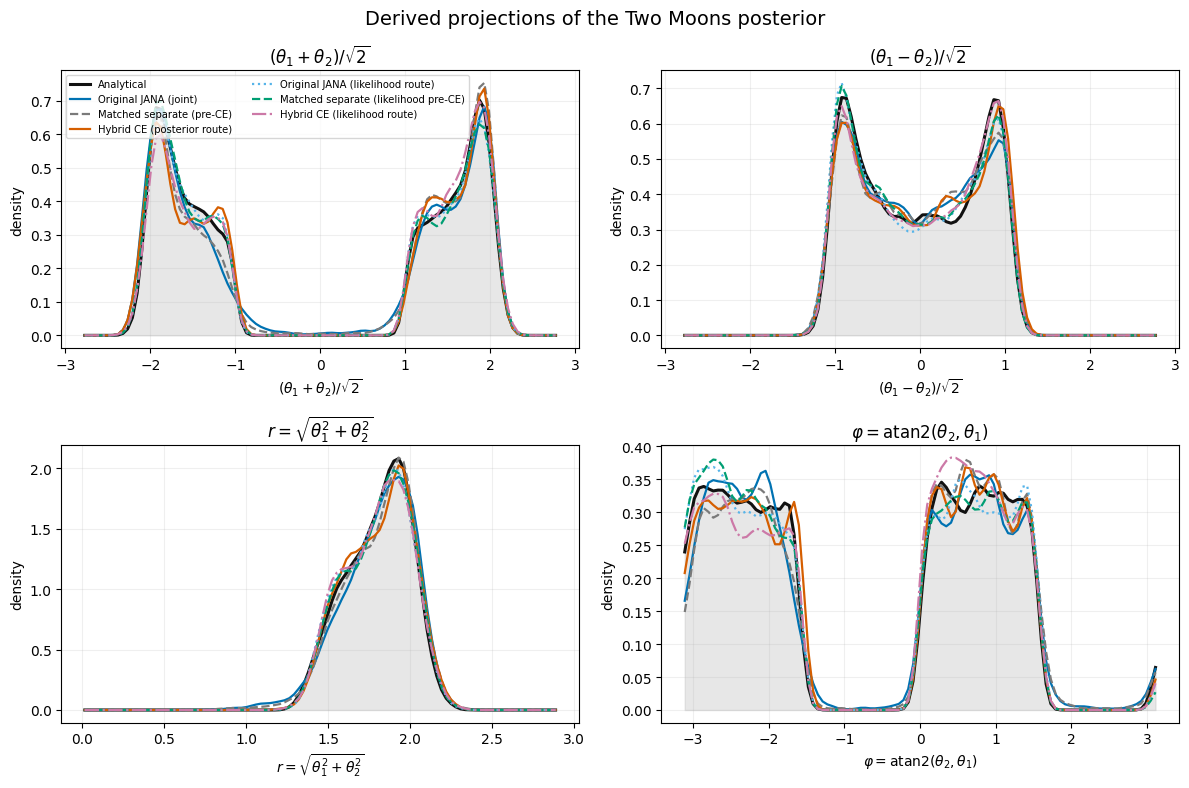

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/03_rotated_radial_angular_projections.png


In [14]:
# Rotated, radial, and angular projections expose discrepancies hidden by theta marginals.
def derived_coordinates(values):
    values = np.asarray(values, dtype=np.float64)
    return {
        r"$(\theta_1+\theta_2)/\sqrt{2}$": (values[:, 0] + values[:, 1]) / np.sqrt(2.0),
        r"$(\theta_1-\theta_2)/\sqrt{2}$": (values[:, 0] - values[:, 1]) / np.sqrt(2.0),
        r"$r=\sqrt{\theta_1^2+\theta_2^2}$": np.linalg.norm(values, axis=1),
        r"$\varphi=\mathrm{atan2}(\theta_2,\theta_1)$": np.arctan2(values[:, 1], values[:, 0]),
    }

derived = {label: derived_coordinates(values) for label, values in diagnostic_samples.items()}
derived_edges = {
    r"$(\theta_1+\theta_2)/\sqrt{2}$": np.linspace(-2.8, 2.8, 101),
    r"$(\theta_1-\theta_2)/\sqrt{2}$": np.linspace(-2.8, 2.8, 101),
    r"$r=\sqrt{\theta_1^2+\theta_2^2}$": np.linspace(0.0, 2.9, 101),
    r"$\varphi=\mathrm{atan2}(\theta_2,\theta_1)$": np.linspace(-np.pi, np.pi, 101),
}

figure, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, quantity in zip(axes.flat, derived_edges):
    centers, truth_density = smoothed_histogram(
        derived[analytical_label][quantity], derived_edges[quantity]
    )
    axis.fill_between(centers, truth_density, color="#BDBDBD", alpha=0.35)
    axis.plot(centers, truth_density, color="#111111", lw=2.2, label="Analytical")
    for label in method_labels:
        _, density = smoothed_histogram(derived[label][quantity], derived_edges[quantity])
        axis.plot(
            centers, density, color=comparison_colors[label],
            ls=comparison_linestyles[label], lw=1.6, label=label,
        )
    axis.set(title=quantity, xlabel=quantity, ylabel="density")
    axis.grid(alpha=0.2)
axes[0, 0].legend(fontsize=7.2, ncol=2)
figure.suptitle("Derived projections of the Two Moons posterior", fontsize=14)
figure.tight_layout()
save_extra_figure(figure, "derived_projections", "03_rotated_radial_angular_projections")

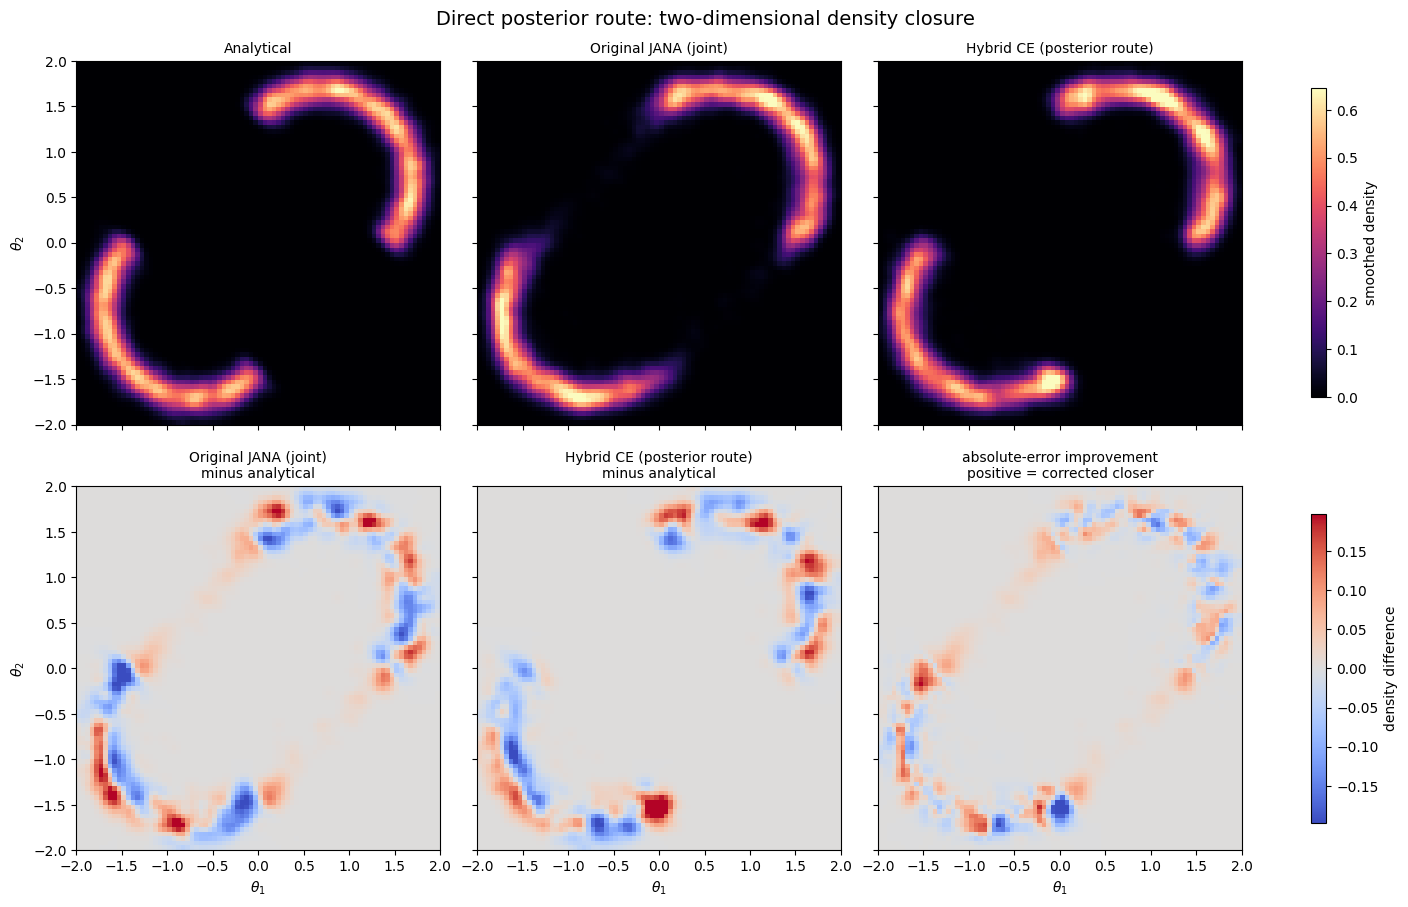

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/04_direct_posterior_2d_density_residuals.png


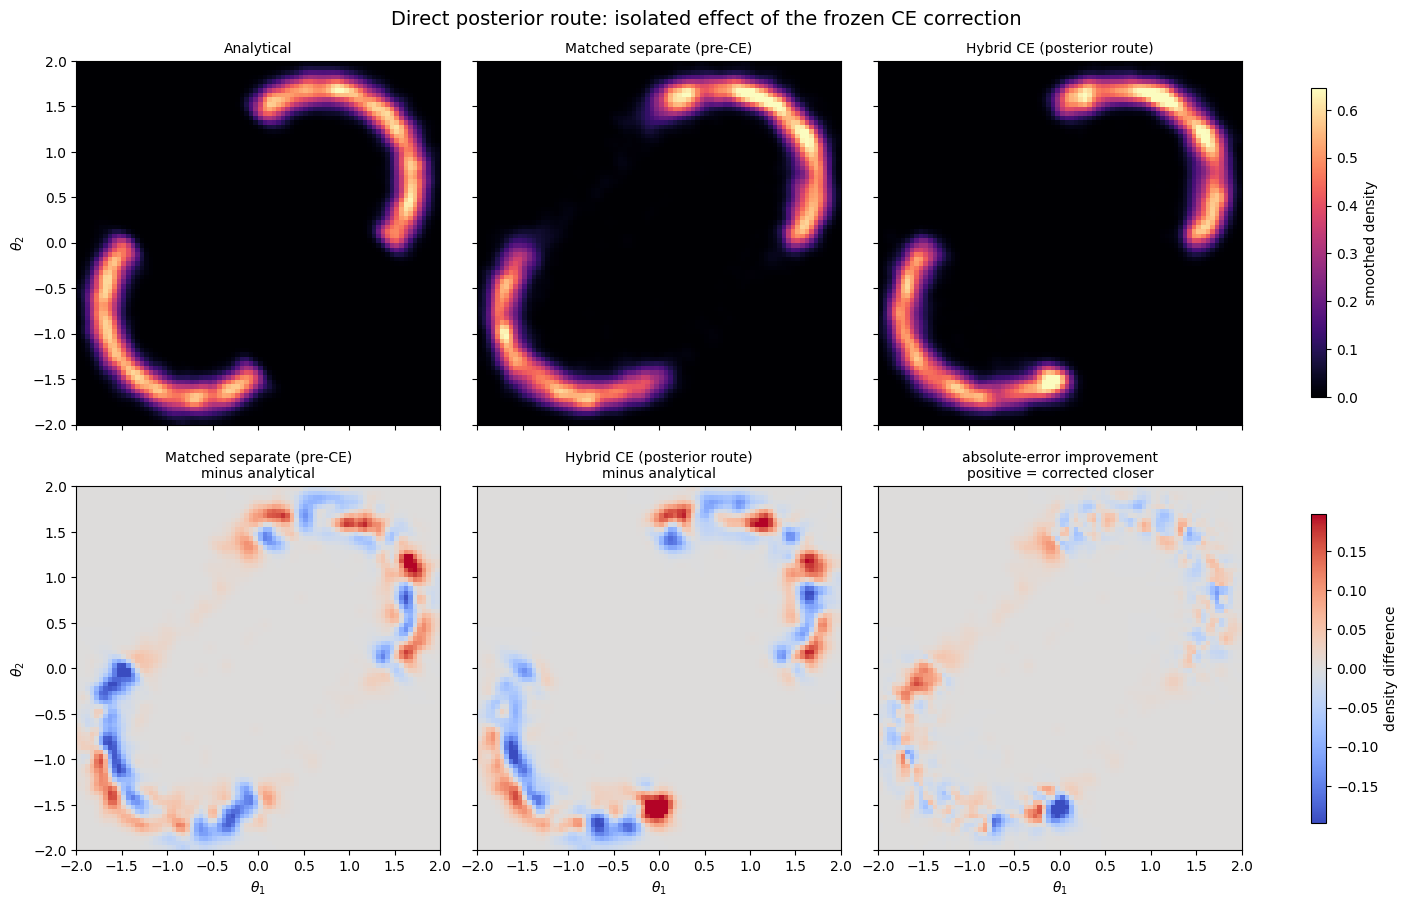

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/04b_direct_posterior_ce_only_effect.png


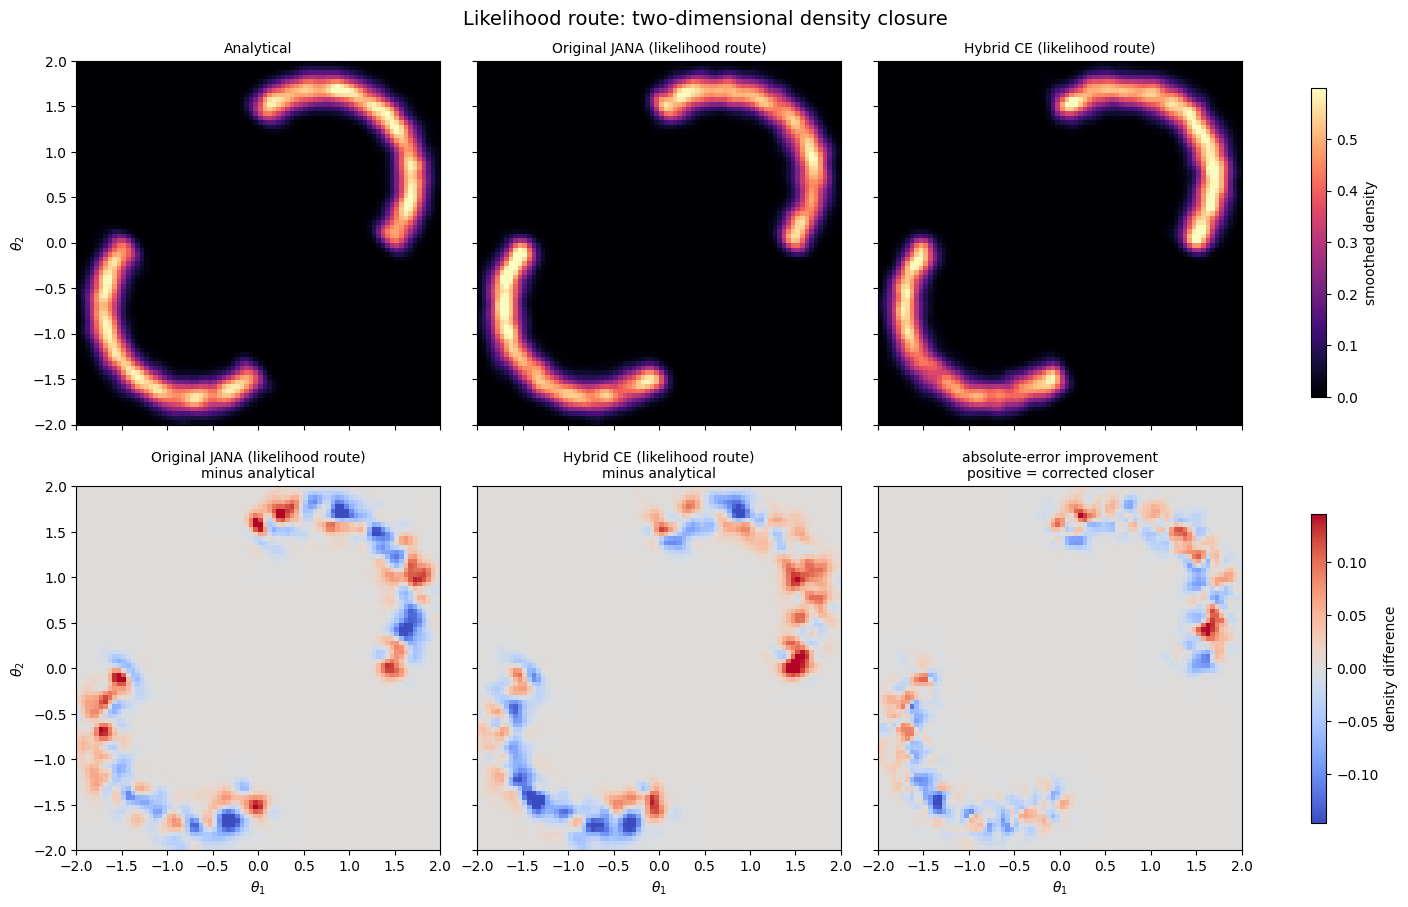

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/05_likelihood_route_2d_density_residuals.png


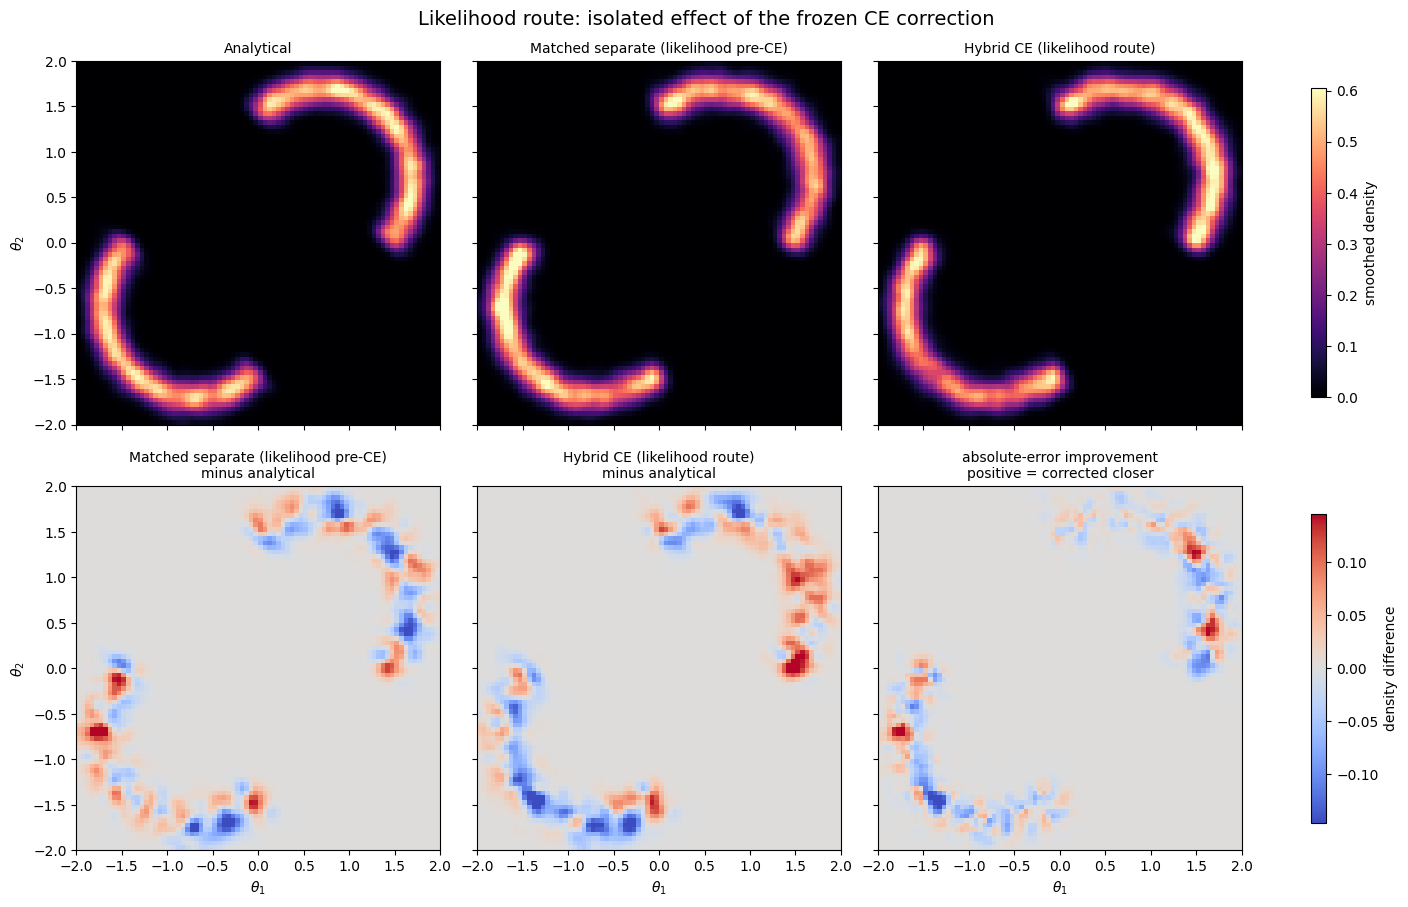

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/05b_likelihood_route_ce_only_effect.png


In [15]:
# Common-bin two-dimensional densities and signed residual maps.
density_edges = np.linspace(-2.0, 2.0, 81)
density_extent = [density_edges[0], density_edges[-1], density_edges[0], density_edges[-1]]
density_bin_area = np.diff(density_edges)[0] ** 2

def smoothed_density_2d(values):
    counts, _, _ = np.histogram2d(
        values[:, 0], values[:, 1], bins=(density_edges, density_edges)
    )
    density = gaussian_filter(counts.astype(np.float64), sigma=1.15, mode="nearest")
    return density / (len(values) * density_bin_area)

density_2d = {
    label: smoothed_density_2d(values)
    for label, values in diagnostic_samples.items()
}

def density_residual_figure(baseline_label, corrected_label, route_title):
    truth = density_2d[analytical_label]
    baseline = density_2d[baseline_label]
    corrected = density_2d[corrected_label]
    baseline_residual = baseline - truth
    corrected_residual = corrected - truth
    improvement = np.abs(baseline_residual) - np.abs(corrected_residual)
    density_vmax = max(
        np.quantile(truth, 0.995), np.quantile(baseline, 0.995),
        np.quantile(corrected, 0.995),
    )
    residual_limit = max(
        np.quantile(np.abs(baseline_residual), 0.995),
        np.quantile(np.abs(corrected_residual), 0.995), 1e-8,
    )
    improvement_limit = max(np.quantile(np.abs(improvement), 0.995), 1e-8)
    residual_limit = max(residual_limit, improvement_limit)
    figure, axes = plt.subplots(
        2, 3, figsize=(14, 9), sharex=True, sharey=True,
        constrained_layout=True,
    )
    top = [
        (truth, "Analytical"),
        (baseline, baseline_label),
        (corrected, corrected_label),
    ]
    for axis, (grid, title) in zip(axes[0], top):
        image_handle = axis.imshow(
            grid.T, origin="lower", extent=density_extent, cmap="magma",
            vmin=0.0, vmax=density_vmax, aspect="equal",
        )
        axis.set_title(title, fontsize=10)
    residuals = [
        (baseline_residual, f"{baseline_label}\nminus analytical", residual_limit),
        (corrected_residual, f"{corrected_label}\nminus analytical", residual_limit),
        (improvement, "absolute-error improvement\npositive = corrected closer", residual_limit),
    ]
    for axis, (grid, title, limit) in zip(axes[1], residuals):
        residual_handle = axis.imshow(
            grid.T, origin="lower", extent=density_extent, cmap="coolwarm",
            norm=TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit), aspect="equal",
        )
        axis.set_title(title, fontsize=10)
    for axis in axes[:, 0]:
        axis.set_ylabel(r"$\theta_2$")
    for axis in axes[-1]:
        axis.set_xlabel(r"$\theta_1$")
    figure.colorbar(image_handle, ax=axes[0].tolist(), shrink=0.8, label="smoothed density")
    figure.colorbar(residual_handle, ax=axes[1].tolist(), shrink=0.8, label="density difference")
    figure.suptitle(route_title, fontsize=14)
    return figure

direct_density_figure = density_residual_figure(
    "Original JANA (joint)", "Hybrid CE (posterior route)",
    "Direct posterior route: two-dimensional density closure",
)
save_extra_figure(
    direct_density_figure, "direct_density_residuals",
    "04_direct_posterior_2d_density_residuals",
)

direct_ce_effect_figure = density_residual_figure(
    "Matched separate (pre-CE)", "Hybrid CE (posterior route)",
    "Direct posterior route: isolated effect of the frozen CE correction",
)
save_extra_figure(
    direct_ce_effect_figure, "direct_ce_effect",
    "04b_direct_posterior_ce_only_effect",
)

likelihood_density_figure = density_residual_figure(
    "Original JANA (likelihood route)", "Hybrid CE (likelihood route)",
    "Likelihood route: two-dimensional density closure",
)
save_extra_figure(
    likelihood_density_figure, "likelihood_density_residuals",
    "05_likelihood_route_2d_density_residuals",
)

likelihood_ce_effect_figure = density_residual_figure(
    "Matched separate (likelihood pre-CE)", "Hybrid CE (likelihood route)",
    "Likelihood route: isolated effect of the frozen CE correction",
)
save_extra_figure(
    likelihood_ce_effect_figure, "likelihood_ce_effect",
    "05b_likelihood_route_ce_only_effect",
)

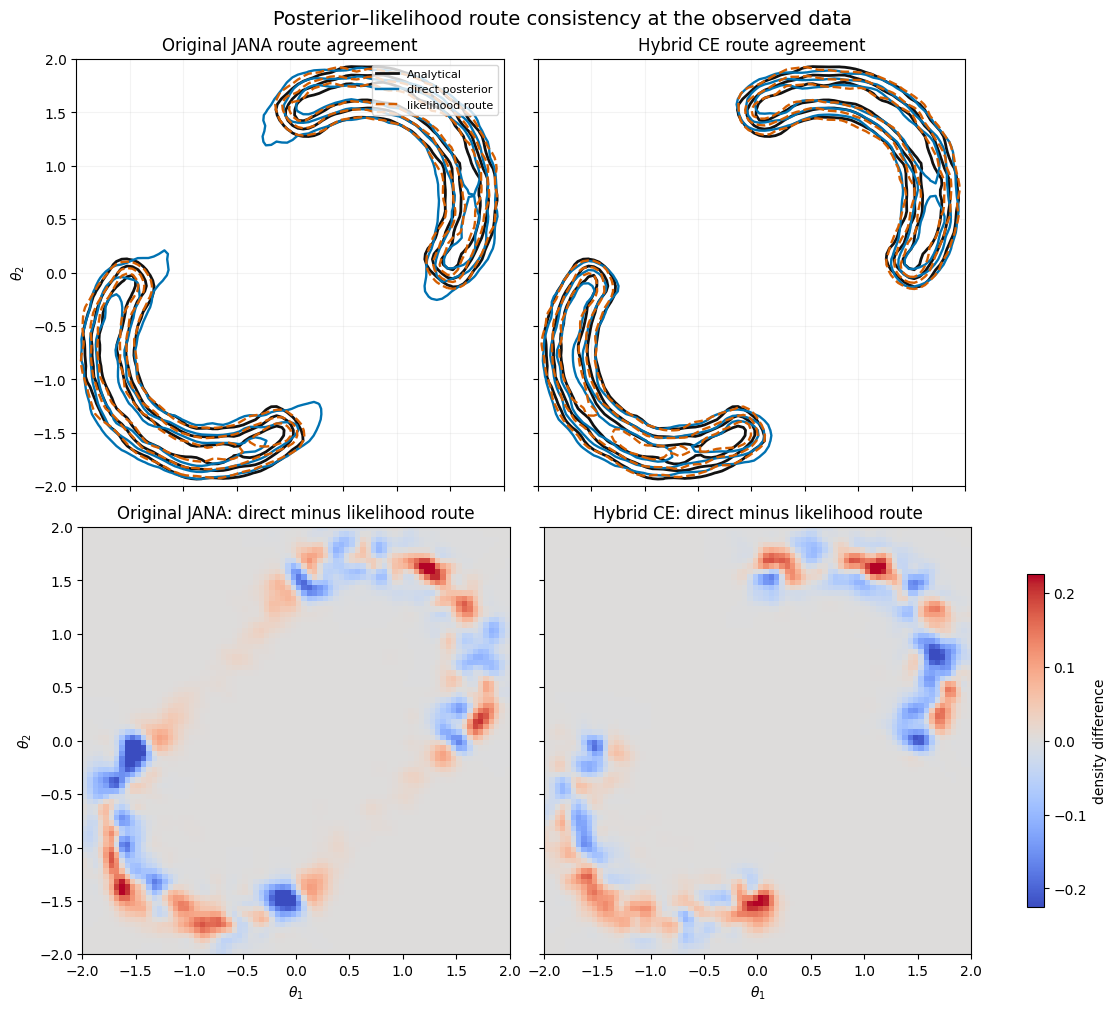

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/06_direct_vs_likelihood_route_consistency.png


In [16]:
# Internal consistency: direct posterior and likelihood routes for each system.
def hdr_thresholds(density, masses=(0.95, 0.80, 0.50)):
    flat = np.sort(np.asarray(density).ravel())[::-1]
    cumulative = np.cumsum(flat) * density_bin_area
    thresholds = []
    for mass in masses:
        index = min(np.searchsorted(cumulative, mass), len(flat) - 1)
        thresholds.append(flat[index])
    return np.unique(np.sort(thresholds))

truth_density = density_2d[analytical_label]
jana_direct_density = density_2d["Original JANA (joint)"]
jana_likelihood_density = density_2d["Original JANA (likelihood route)"]
hybrid_direct_density = density_2d["Hybrid CE (posterior route)"]
hybrid_likelihood_density = density_2d["Hybrid CE (likelihood route)"]

centers_2d = 0.5 * (density_edges[:-1] + density_edges[1:])
figure, axes = plt.subplots(
    2, 2, figsize=(11, 10), sharex=True, sharey=True,
    constrained_layout=True,
)
contour_specs = [
    (axes[0, 0], jana_direct_density, jana_likelihood_density, "Original JANA route agreement"),
    (axes[0, 1], hybrid_direct_density, hybrid_likelihood_density, "Hybrid CE route agreement"),
]
for axis, direct_density, likelihood_density, title in contour_specs:
    axis.contour(
        centers_2d, centers_2d, truth_density.T,
        levels=hdr_thresholds(truth_density), colors="#111111", linewidths=2.0,
    )
    axis.contour(
        centers_2d, centers_2d, direct_density.T,
        levels=hdr_thresholds(direct_density), colors="#0072B2", linewidths=1.7,
    )
    axis.contour(
        centers_2d, centers_2d, likelihood_density.T,
        levels=hdr_thresholds(likelihood_density), colors="#D55E00", linewidths=1.7,
        linestyles="--",
    )
    axis.set_title(title)
    axis.set_aspect("equal")
    axis.grid(alpha=0.15)

route_differences = [
    jana_direct_density - jana_likelihood_density,
    hybrid_direct_density - hybrid_likelihood_density,
]
route_titles = [
    "Original JANA: direct minus likelihood route",
    "Hybrid CE: direct minus likelihood route",
]
route_limit = max(
    np.quantile(np.abs(route_differences[0]), 0.995),
    np.quantile(np.abs(route_differences[1]), 0.995), 1e-8,
)
for axis, difference, title in zip(axes[1], route_differences, route_titles):
    route_handle = axis.imshow(
        difference.T, origin="lower", extent=density_extent, cmap="coolwarm",
        norm=TwoSlopeNorm(vmin=-route_limit, vcenter=0.0, vmax=route_limit),
        aspect="equal",
    )
    axis.set_title(title)
legend_handles = [
    Line2D([0], [0], color="#111111", lw=2.0, label="Analytical"),
    Line2D([0], [0], color="#0072B2", lw=1.7, label="direct posterior"),
    Line2D([0], [0], color="#D55E00", lw=1.7, ls="--", label="likelihood route"),
]
axes[0, 0].legend(handles=legend_handles, fontsize=8)
for axis in axes[:, 0]:
    axis.set_ylabel(r"$\theta_2$")
for axis in axes[-1]:
    axis.set_xlabel(r"$\theta_1$")
figure.colorbar(route_handle, ax=axes[1].tolist(), shrink=0.78, label="density difference")
figure.suptitle("Posterior–likelihood route consistency at the observed data", fontsize=14)
save_extra_figure(figure, "route_consistency", "06_direct_vs_likelihood_route_consistency")

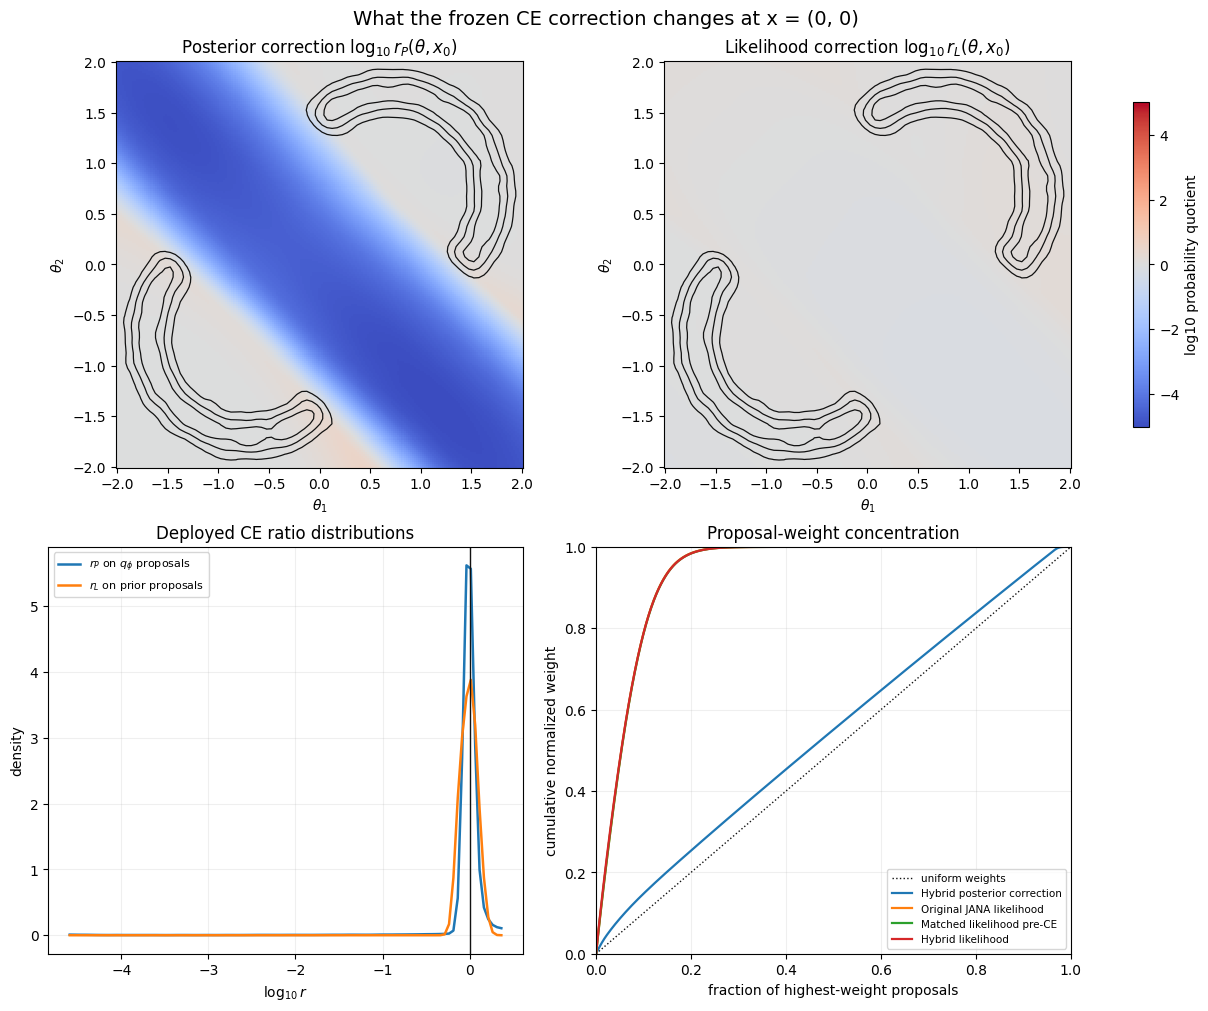

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/07_ce_fields_ratios_and_weight_concentration.png


In [17]:
# Frozen CE correction fields, ratio distributions, and weight concentration.
ratio_axis = np.linspace(-2.0, 2.0, 201)
ratio_theta_1, ratio_theta_2 = np.meshgrid(ratio_axis, ratio_axis, indexing="xy")
ratio_theta = np.column_stack([ratio_theta_1.ravel(), ratio_theta_2.ravel()])
ratio_grid_points = np.column_stack([ratio_theta, np.zeros_like(ratio_theta)])
ratio_fields = predict_ratios(ratio_grid_points).reshape(len(ratio_axis), len(ratio_axis), 2)
log10_r_p_field = np.log10(ratio_fields[:, :, 0])
log10_r_l_field = np.log10(ratio_fields[:, :, 1])
field_limit = max(
    np.quantile(np.abs(log10_r_p_field), 0.995),
    np.quantile(np.abs(log10_r_l_field), 0.995), 0.05,
)

figure, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for axis, field, title in [
    (axes[0, 0], log10_r_p_field, r"Posterior correction $\log_{10} r_P(\theta,x_0)$"),
    (axes[0, 1], log10_r_l_field, r"Likelihood correction $\log_{10} r_L(\theta,x_0)$"),
]:
    field_handle = axis.pcolormesh(
        ratio_axis, ratio_axis, field, shading="auto", cmap="coolwarm",
        norm=TwoSlopeNorm(vmin=-field_limit, vcenter=0.0, vmax=field_limit),
    )
    axis.contour(
        centers_2d, centers_2d, truth_density.T,
        levels=hdr_thresholds(truth_density), colors="#111111", linewidths=0.9,
    )
    axis.set(title=title, xlabel=r"$\theta_1$", ylabel=r"$\theta_2$")
    axis.set_aspect("equal")
figure.colorbar(field_handle, ax=axes[0].tolist(), shrink=0.8, label="log10 probability quotient")

ratio_logs = {
    r"$r_P$ on $q_\phi$ proposals": np.log10(proposal_r_p),
    r"$r_L$ on prior proposals": np.log10(prior_ratios[:, 1]),
}
ratio_low = min(np.quantile(values, 0.002) for values in ratio_logs.values())
ratio_high = max(np.quantile(values, 0.998) for values in ratio_logs.values())
ratio_edges = np.linspace(ratio_low, ratio_high, 101)
for label, values in ratio_logs.items():
    centers, density = smoothed_histogram(values, ratio_edges, sigma=1.0)
    axes[1, 0].plot(centers, density, lw=1.8, label=label)
axes[1, 0].axvline(0.0, color="#111111", lw=1.0)
axes[1, 0].set(
    title="Deployed CE ratio distributions", xlabel=r"$\log_{10} r$", ylabel="density",
)
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.2)

concentration_weights = {
    "Hybrid posterior correction": hybrid_posterior_weights,
    "Original JANA likelihood": joint_likelihood_weights,
    "Matched likelihood pre-CE": matched_likelihood_weights,
    "Hybrid likelihood": hybrid_likelihood_weights,
}
axes[1, 1].plot([0, 1], [0, 1], color="#111111", lw=1.0, ls=":", label="uniform weights")
for label, weights in concentration_weights.items():
    ordered = np.sort(np.asarray(weights, dtype=np.float64))[::-1]
    cumulative = np.cumsum(ordered)
    fraction = np.arange(1, len(ordered) + 1) / len(ordered)
    axes[1, 1].plot(fraction, cumulative, lw=1.6, label=label)
axes[1, 1].set(
    title="Proposal-weight concentration", xlabel="fraction of highest-weight proposals",
    ylabel="cumulative normalized weight", xlim=(0, 1), ylim=(0, 1),
)
axes[1, 1].legend(fontsize=7.5)
axes[1, 1].grid(alpha=0.2)

figure.suptitle("What the frozen CE correction changes at x = (0, 0)", fontsize=14)
save_extra_figure(figure, "correction_fields", "07_ce_fields_ratios_and_weight_concentration")

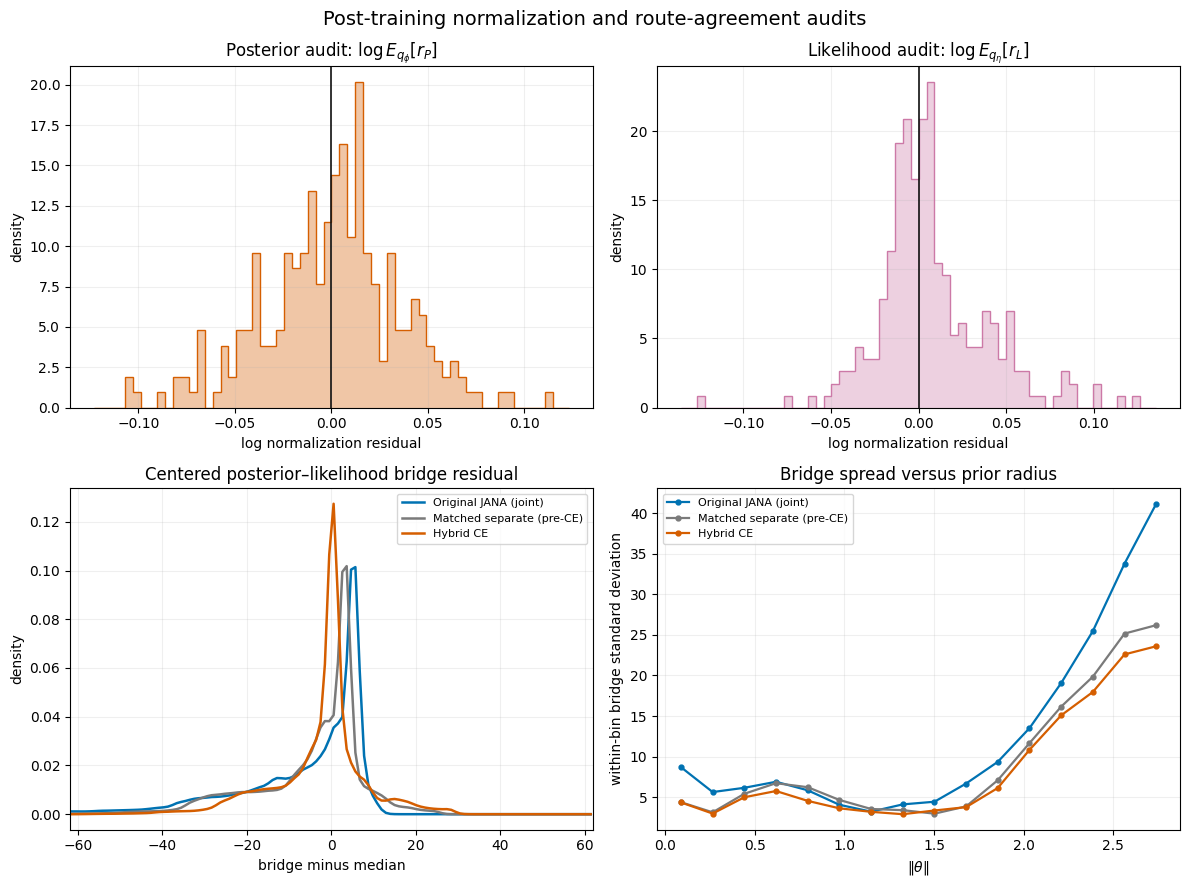

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/08_normalization_and_bridge_distributions.png


In [18]:
# Normalization identities and bridge-disagreement distributions.
figure, axes = plt.subplots(2, 2, figsize=(12, 9))
for axis, values, color, title in [
    (axes[0, 0], np.log(z_p), "#D55E00", r"Posterior audit: $\log E_{q_\phi}[r_P]$"),
    (axes[0, 1], np.log(z_l), "#CC79A7", r"Likelihood audit: $\log E_{q_\eta}[r_L]$"),
]:
    limit = max(np.quantile(np.abs(values), 0.995), 1e-3)
    edges = np.linspace(-limit, limit, 61)
    axis.hist(values, bins=edges, density=True, histtype="stepfilled", alpha=0.35, color=color)
    axis.hist(values, bins=edges, density=True, histtype="step", lw=1.8, color=color)
    axis.axvline(0.0, color="#111111", lw=1.2)
    axis.set(title=title, xlabel="log normalization residual", ylabel="density")
    axis.grid(alpha=0.2)

bridge_values = {
    "Original JANA (joint)": np.asarray(pure_bridge),
    "Matched separate (pre-CE)": np.asarray(separate_bridge),
    "Hybrid CE": np.asarray(corrected_bridge),
}
centered_bridge = {
    label: values - np.median(values) for label, values in bridge_values.items()
}
bridge_limit = max(np.quantile(np.abs(values), 0.99) for values in centered_bridge.values())
bridge_edges = np.linspace(-bridge_limit, bridge_limit, 121)
bridge_colors = {
    "Original JANA (joint)": comparison_colors["Original JANA (joint)"],
    "Matched separate (pre-CE)": comparison_colors["Matched separate (pre-CE)"],
    "Hybrid CE": comparison_colors["Hybrid CE (posterior route)"],
}
for label, values in centered_bridge.items():
    centers, density = smoothed_histogram(values, bridge_edges, sigma=1.0)
    axes[1, 0].plot(centers, density, lw=1.8, color=bridge_colors[label], label=label)
axes[1, 0].set(
    title="Centered posterior–likelihood bridge residual", xlabel="bridge minus median",
    ylabel="density", xlim=(-bridge_limit, bridge_limit),
)
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.2)

prior_radius = np.linalg.norm(prior_theta, axis=1)
radius_edges = np.linspace(0.0, np.sqrt(8.0), 17)
radius_centers = 0.5 * (radius_edges[:-1] + radius_edges[1:])
for label, values in bridge_values.items():
    binned_std = []
    for low, high in zip(radius_edges[:-1], radius_edges[1:]):
        selected = values[(prior_radius >= low) & (prior_radius < high)]
        binned_std.append(np.std(selected) if len(selected) > 20 else np.nan)
    axes[1, 1].plot(
        radius_centers, binned_std, marker="o", ms=3.5, lw=1.6,
        color=bridge_colors[label], label=label,
    )
axes[1, 1].set(
    title="Bridge spread versus prior radius", xlabel=r"$\|\theta\|$",
    ylabel="within-bin bridge standard deviation",
)
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.2)

figure.suptitle("Post-training normalization and route-agreement audits", fontsize=14)
figure.tight_layout()
save_extra_figure(figure, "normalization_bridge", "08_normalization_and_bridge_distributions")

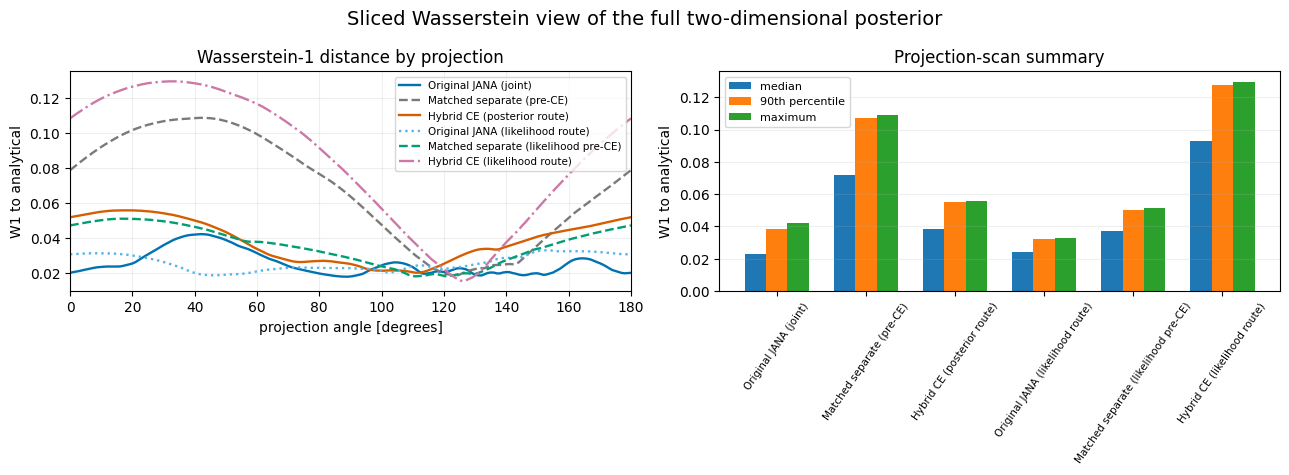

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/09_sliced_wasserstein_projection_scan.png


In [19]:
# Sliced Wasserstein scan over every one-dimensional projection angle.
projection_angles = np.linspace(0.0, np.pi, 181)
directions = np.column_stack([np.cos(projection_angles), np.sin(projection_angles)])
sliced_wasserstein = {}
truth_values = diagnostic_samples[analytical_label]
for label in method_labels:
    values = diagnostic_samples[label]
    distances = []
    for direction in directions:
        truth_projection = np.sort(truth_values @ direction)
        method_projection = np.sort(values @ direction)
        distances.append(np.mean(np.abs(method_projection - truth_projection)))
    sliced_wasserstein[label] = np.asarray(distances)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
angle_degrees = np.degrees(projection_angles)
for label, distances in sliced_wasserstein.items():
    axes[0].plot(
        angle_degrees, distances, color=comparison_colors[label],
        ls=comparison_linestyles[label], lw=1.7, label=label,
    )
axes[0].set(
    title="Wasserstein-1 distance by projection", xlabel="projection angle [degrees]",
    ylabel="W1 to analytical", xlim=(0, 180),
)
axes[0].legend(fontsize=7.5)
axes[0].grid(alpha=0.2)

summary_names = list(sliced_wasserstein)
summary_values = np.asarray([
    [np.median(sliced_wasserstein[label]), np.quantile(sliced_wasserstein[label], 0.90),
     np.max(sliced_wasserstein[label])]
    for label in summary_names
])
x_positions = np.arange(len(summary_names))
bar_width = 0.24
for offset, column, statistic in [(-bar_width, 0, "median"), (0.0, 1, "90th percentile"), (bar_width, 2, "maximum")]:
    axes[1].bar(x_positions + offset, summary_values[:, column], width=bar_width, label=statistic)
axes[1].set(
    title="Projection-scan summary", ylabel="W1 to analytical",
    xticks=x_positions, xticklabels=summary_names,
)
axes[1].tick_params(axis="x", rotation=55, labelsize=7.5)
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.2)
figure.suptitle("Sliced Wasserstein view of the full two-dimensional posterior", fontsize=14)
figure.tight_layout()
save_extra_figure(figure, "sliced_wasserstein", "09_sliced_wasserstein_projection_scan")

sliced_rows = []
for label, distances in sliced_wasserstein.items():
    sliced_rows.extend({
        "method": label, "angle_degrees": float(angle), "W1": float(distance)
    } for angle, distance in zip(angle_degrees, distances))
sliced_wasserstein_path = EXTRA_FIGURE_DIR / "sliced_wasserstein_scan.csv"
pd.DataFrame(sliced_rows).to_csv(sliced_wasserstein_path, index=False)

,method,coordinate,q02.5,q16,median,q84,q97.5
0,Analytical,theta_1,-1.774267,-1.571948,0.013234,1.563447,1.771646
1,Analytical,theta_2,-1.770005,-1.553343,0.019979,1.556380,1.767001
2,Original JANA (joint),theta_1,-1.771813,-1.588569,0.053562,1.567226,1.769100
3,Original JANA (joint),theta_2,-1.753475,-1.548985,0.049065,1.565038,1.748026
4,Matched separate (pre-CE),theta_1,-1.778132,-1.559723,0.143812,1.589189,1.790157
5,Matched separate (pre-CE),theta_2,-1.749639,-1.536605,0.192999,1.571308,1.751893
6,Hybrid CE (posterior route),theta_1,-1.789082,-1.566533,0.076248,1.577477,1.782083
7,Hybrid CE (posterior route),theta_2,-1.742881,-1.546071,0.059198,1.574794,1.744945
8,Original JANA (likelihood route),theta_1,-1.789364,-1.592314,-0.004073,1.556931,1.780044
9,Original JANA (likelihood route),theta_2,-1.751133,-1.529646,-0.023157,1.562318,1.757144


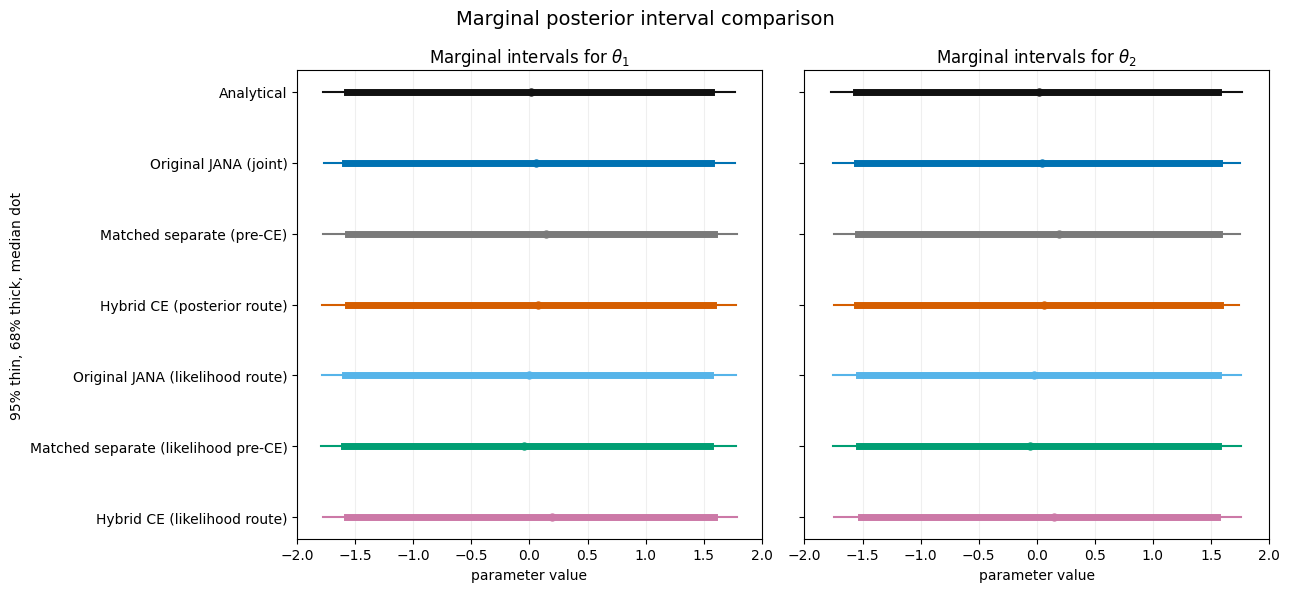

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/10_marginal_credible_intervals.png


In [20]:
# Marginal credible-interval and median comparison.
interval_rows = []
for label, values in diagnostic_samples.items():
    for coordinate, symbol in enumerate(("theta_1", "theta_2")):
        quantiles = np.quantile(values[:, coordinate], [0.025, 0.16, 0.50, 0.84, 0.975])
        interval_rows.append({
            "method": label, "coordinate": symbol,
            "q02.5": quantiles[0], "q16": quantiles[1], "median": quantiles[2],
            "q84": quantiles[3], "q97.5": quantiles[4],
        })
interval_table = pd.DataFrame(interval_rows)
display(interval_table)
interval_path = EXTRA_FIGURE_DIR / "marginal_credible_intervals.csv"
interval_table.to_csv(interval_path, index=False)

figure, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
ordered_labels = list(diagnostic_samples)
y_positions = np.arange(len(ordered_labels))[::-1]
coordinate_symbols = {"theta_1": r"$\theta_1$", "theta_2": r"$\theta_2$"}
for coordinate, axis in zip(("theta_1", "theta_2"), axes):
    selected = interval_table[interval_table["coordinate"] == coordinate].set_index("method")
    for y_position, label in zip(y_positions, ordered_labels):
        row = selected.loc[label]
        color = comparison_colors[label]
        axis.plot([row["q02.5"], row["q97.5"]], [y_position, y_position], color=color, lw=1.5)
        axis.plot([row["q16"], row["q84"]], [y_position, y_position], color=color, lw=5.0)
        axis.plot(row["median"], y_position, marker="o", color=color, ms=5)
    axis.set(
        title=f"Marginal intervals for {coordinate_symbols[coordinate]}",
        xlabel="parameter value", yticks=y_positions, yticklabels=ordered_labels,
        xlim=(-2.0, 2.0),
    )
    axis.grid(axis="x", alpha=0.2)
axes[0].set_ylabel("95% thin, 68% thick, median dot")
figure.suptitle("Marginal posterior interval comparison", fontsize=14)
figure.tight_layout()
save_extra_figure(figure, "credible_intervals", "10_marginal_credible_intervals")

,paper multiscale MMD,mean marginal W1,max marginal KS,median sliced W1,max sliced W1,multivariate energy distance,mean-vector shift,covariance Frobenius shift,fraction outside prior
method,,,,,,,,,
Original JANA (joint),0.116700,0.019228,0.0199,0.023239,0.042369,0.050307,0.004704,0.031404,0.0005
Matched separate (pre-CE),0.131905,0.071365,0.0382,0.071921,0.108761,0.080652,0.098446,0.020182,0.0005
Hybrid CE (posterior route),0.164659,0.038672,0.0348,0.038546,0.055947,0.042685,0.048690,0.018290,0.0006
Original JANA (likelihood route),0.117134,0.026916,0.0210,0.024306,0.033136,0.061377,0.030914,0.052521,0.0000
Matched separate (likelihood pre-CE),0.126540,0.037973,0.0232,0.037066,0.051173,0.029659,0.048799,0.048391,0.0000
Hybrid CE (likelihood route),0.180126,0.091705,0.0468,0.093171,0.129604,0.103270,0.128041,0.094445,0.0000


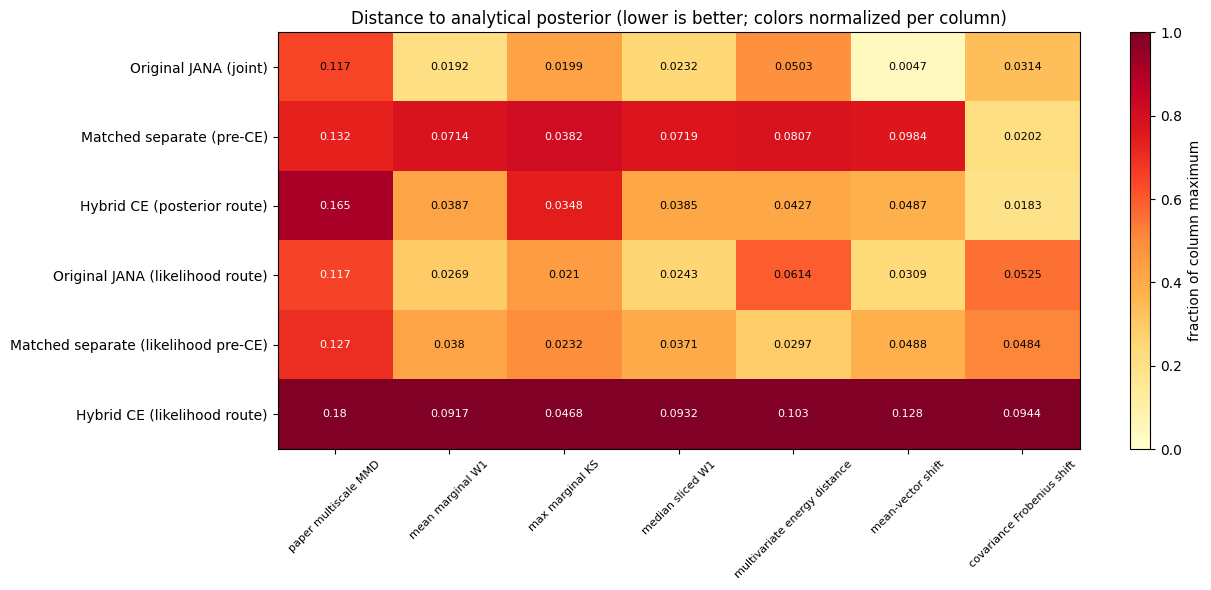

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/11_expanded_metric_heatmap.png


In [21]:
# Multi-metric comparison to analytical truth, with identical sample counts.
from scipy.spatial.distance import cdist

def equal_size_wasserstein_1d(left, right):
    return float(np.mean(np.abs(np.sort(left) - np.sort(right))))

metric_lookup = metric_table.set_index("method")["paper multiscale MMD"].to_dict()
legacy_metric_names = {
    "Original JANA (joint)": "Original JANA q_phi",
    "Matched separate (pre-CE)": "Matched separate q_phi",
    "Hybrid CE (posterior route)": "Hybrid q_phi + CE",
    "Original JANA (likelihood route)": "Original JANA q_eta route",
    "Matched separate (likelihood pre-CE)": None,
    "Hybrid CE (likelihood route)": "Hybrid q_eta + CE",
}
energy_size = min(1_500, diagnostic_size)
energy_rng = np.random.default_rng(SEED + 50_101)
energy_indices = {
    label: energy_rng.choice(len(values), size=energy_size, replace=False)
    for label, values in diagnostic_samples.items()
}
truth_energy = diagnostic_samples[analytical_label][energy_indices[analytical_label]]
truth_covariance = np.cov(diagnostic_samples[analytical_label].T)
metric_summary_rows = []
for label in method_labels:
    truth = diagnostic_samples[analytical_label]
    values = diagnostic_samples[label]
    marginal_w1 = [
        equal_size_wasserstein_1d(truth[:, coordinate], values[:, coordinate])
        for coordinate in range(2)
    ]
    marginal_ks = [
        ks_2samp(truth[:, coordinate], values[:, coordinate]).statistic
        for coordinate in range(2)
    ]
    method_energy = values[energy_indices[label]]
    energy_squared = (
        2.0 * cdist(truth_energy, method_energy).mean()
        - cdist(truth_energy, truth_energy).mean()
        - cdist(method_energy, method_energy).mean()
    )
    metric_summary_rows.append({
        "method": label,
        "paper multiscale MMD": (
            metric_lookup[legacy_metric_names[label]]
            if legacy_metric_names[label] is not None
            else paper_mmd(reference_1000, values[:1_000])
        ),
        "mean marginal W1": float(np.mean(marginal_w1)),
        "max marginal KS": float(np.max(marginal_ks)),
        "median sliced W1": float(np.median(sliced_wasserstein[label])),
        "max sliced W1": float(np.max(sliced_wasserstein[label])),
        "multivariate energy distance": float(np.sqrt(max(energy_squared, 0.0))),
        "mean-vector shift": float(np.linalg.norm(values.mean(axis=0) - truth.mean(axis=0))),
        "covariance Frobenius shift": float(np.linalg.norm(np.cov(values.T) - truth_covariance)),
        "fraction outside prior": float(1.0 - inside_prior(values).mean()),
    })
expanded_metric_table = pd.DataFrame(metric_summary_rows).set_index("method")
display(expanded_metric_table)
expanded_metric_path = EXTRA_FIGURE_DIR / "expanded_distribution_metrics.csv"
expanded_metric_table.to_csv(expanded_metric_path)

heatmap_columns = [
    "paper multiscale MMD", "mean marginal W1", "max marginal KS",
    "median sliced W1", "multivariate energy distance",
    "mean-vector shift", "covariance Frobenius shift",
]
heatmap_values = expanded_metric_table[heatmap_columns].to_numpy(dtype=np.float64)
column_scale = np.maximum(heatmap_values.max(axis=0, keepdims=True), 1e-12)
normalized_heatmap = heatmap_values / column_scale
figure, axis = plt.subplots(figsize=(13, 6))
heatmap_handle = axis.imshow(normalized_heatmap, cmap="YlOrRd", vmin=0.0, vmax=1.0, aspect="auto")
for row in range(heatmap_values.shape[0]):
    for column in range(heatmap_values.shape[1]):
        text_color = "white" if normalized_heatmap[row, column] > 0.65 else "black"
        axis.text(
            column, row, f"{heatmap_values[row, column]:.3g}",
            ha="center", va="center", fontsize=8, color=text_color,
        )
axis.set(
    title="Distance to analytical posterior (lower is better; colors normalized per column)",
    xticks=np.arange(len(heatmap_columns)), xticklabels=heatmap_columns,
    yticks=np.arange(len(expanded_metric_table)), yticklabels=expanded_metric_table.index,
)
axis.tick_params(axis="x", rotation=45, labelsize=8)
figure.colorbar(heatmap_handle, ax=axis, label="fraction of column maximum")
figure.tight_layout()
save_extra_figure(figure, "expanded_metrics", "11_expanded_metric_heatmap")

,member,RMS log E_qphi[r_P],RMS log E_qeta[r_L],posterior ESS fraction,likelihood ESS fraction
0,1,0.047194,0.044899,0.934702,0.141132
1,2,0.044759,0.046111,0.955163,0.141700
2,3,0.067539,0.053601,0.860983,0.140684
3,4,0.055679,0.061450,0.902264,0.141276
4,5,0.048064,0.043781,0.939619,0.141630
5,6,0.048489,0.044202,0.940335,0.141420
6,7,0.038359,0.043047,0.947356,0.141476
7,8,0.056160,0.041856,0.944853,0.142852
8,9,0.047149,0.036336,0.960142,0.142139
9,10,0.046491,0.041350,0.904288,0.140949


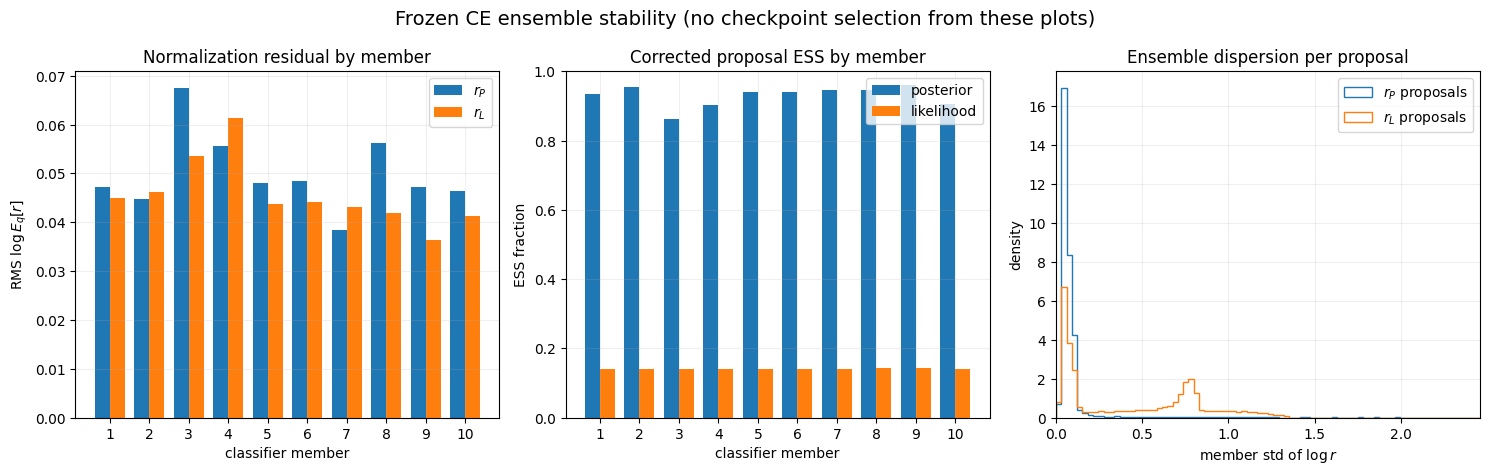

Saved: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/comparison_diagnostics/12_classifier_ensemble_stability.png


In [22]:
# Member-to-member uncertainty of the frozen ten-network CE ensemble.
@torch.no_grad()
def predict_member_ratios(points, batch_size=16_384):
    points = np.asarray(points, dtype=np.float32)
    member_chunks = [[] for _ in classifier]
    tiny = torch.finfo(torch.float64).tiny
    for start in range(0, len(points), int(batch_size)):
        standardized = transform_classifier_points(points[start:start + int(batch_size)])
        tensor = torch.as_tensor(standardized, device=device)
        for member, pack in enumerate(classifier):
            probabilities = torch.softmax(pack["model"](tensor).to(torch.float64), dim=1)
            member_chunks[member].append(torch.column_stack([
                probabilities[:, CLASS_S] / probabilities[:, CLASS_P].clamp_min(tiny),
                probabilities[:, CLASS_S] / probabilities[:, CLASS_L].clamp_min(tiny),
            ]).cpu().numpy())
    return np.stack([np.concatenate(chunks, axis=0) for chunks in member_chunks])

member_p_audit = predict_member_ratios(audit_p_points)[:, :, 0]
member_l_audit = predict_member_ratios(audit_l_points)[:, :, 1]
member_normalization = []
for member in range(len(classifier)):
    member_z_p = grouped_means(member_p_audit[member], audit_p_group)
    member_z_l = grouped_means(member_l_audit[member], audit_l_group)
    member_normalization.append([
        np.sqrt(np.mean(np.log(member_z_p) ** 2)),
        np.sqrt(np.mean(np.log(member_z_l) ** 2)),
    ])
member_normalization = np.asarray(member_normalization)

ensemble_rng = np.random.default_rng(SEED + 50_201)
ensemble_size = min(20_000, len(separate_proposal), len(prior_theta))
posterior_index = ensemble_rng.choice(len(separate_proposal), size=ensemble_size, replace=False)
likelihood_index = ensemble_rng.choice(len(prior_theta), size=ensemble_size, replace=False)
posterior_member_ratios = predict_member_ratios(proposal_points[posterior_index])[:, :, 0]
likelihood_member_ratios = predict_member_ratios(prior_points[likelihood_index])[:, :, 1]
posterior_member_ess = []
likelihood_member_ess = []
for member in range(len(classifier)):
    posterior_weights = normalized_positive(posterior_member_ratios[member])
    likelihood_weights = normalized_from_log(
        legacy["separate_log_likelihood"][likelihood_index]
        + np.log(likelihood_member_ratios[member])
    )
    posterior_member_ess.append(ess(posterior_weights) / ensemble_size)
    likelihood_member_ess.append(ess(likelihood_weights) / ensemble_size)

member_ids = np.arange(1, len(classifier) + 1)
ensemble_diagnostics = pd.DataFrame({
    "member": member_ids,
    "RMS log E_qphi[r_P]": member_normalization[:, 0],
    "RMS log E_qeta[r_L]": member_normalization[:, 1],
    "posterior ESS fraction": posterior_member_ess,
    "likelihood ESS fraction": likelihood_member_ess,
})
display(ensemble_diagnostics)
ensemble_diagnostics_path = EXTRA_FIGURE_DIR / "classifier_member_diagnostics.csv"
ensemble_diagnostics.to_csv(ensemble_diagnostics_path, index=False)

figure, axes = plt.subplots(1, 3, figsize=(15, 4.8))
width = 0.38
axes[0].bar(member_ids - width / 2, member_normalization[:, 0], width, label=r"$r_P$")
axes[0].bar(member_ids + width / 2, member_normalization[:, 1], width, label=r"$r_L$")
axes[0].set(
    title="Normalization residual by member", xlabel="classifier member",
    ylabel=r"RMS $\log E_q[r]$", xticks=member_ids,
)
axes[0].legend()

axes[1].bar(member_ids - width / 2, posterior_member_ess, width, label="posterior")
axes[1].bar(member_ids + width / 2, likelihood_member_ess, width, label="likelihood")
axes[1].set(
    title="Corrected proposal ESS by member", xlabel="classifier member",
    ylabel="ESS fraction", xticks=member_ids, ylim=(0.0, 1.0),
)
axes[1].legend()

posterior_log_spread = np.std(np.log(posterior_member_ratios), axis=0)
likelihood_log_spread = np.std(np.log(likelihood_member_ratios), axis=0)
spread_high = max(
    np.quantile(posterior_log_spread, 0.995),
    np.quantile(likelihood_log_spread, 0.995), 1e-3,
)
spread_edges = np.linspace(0.0, spread_high, 81)
axes[2].hist(
    posterior_log_spread, bins=spread_edges, density=True,
    histtype="step", lw=1.8, label=r"$r_P$ proposals",
)
axes[2].hist(
    likelihood_log_spread, bins=spread_edges, density=True,
    histtype="step", lw=1.8, label=r"$r_L$ proposals",
)
axes[2].set(
    title="Ensemble dispersion per proposal", xlabel=r"member std of $\log r$",
    ylabel="density", xlim=(0.0, spread_high),
)
axes[2].legend()
for axis in axes:
    axis.grid(alpha=0.2)
figure.suptitle("Frozen CE ensemble stability (no checkpoint selection from these plots)", fontsize=14)
figure.tight_layout()
save_extra_figure(figure, "ensemble_stability", "12_classifier_ensemble_stability")

## 6. Training histories

These curves are monitoring outputs from the already completed flow and CE campaigns. They are not used to choose or alter any of the distribution-comparison results above.

joint JANA JSON shape: (20032, 3)
separate posterior JSON shape: (20032, 2)
separate likelihood JSON shape: (20032, 2)


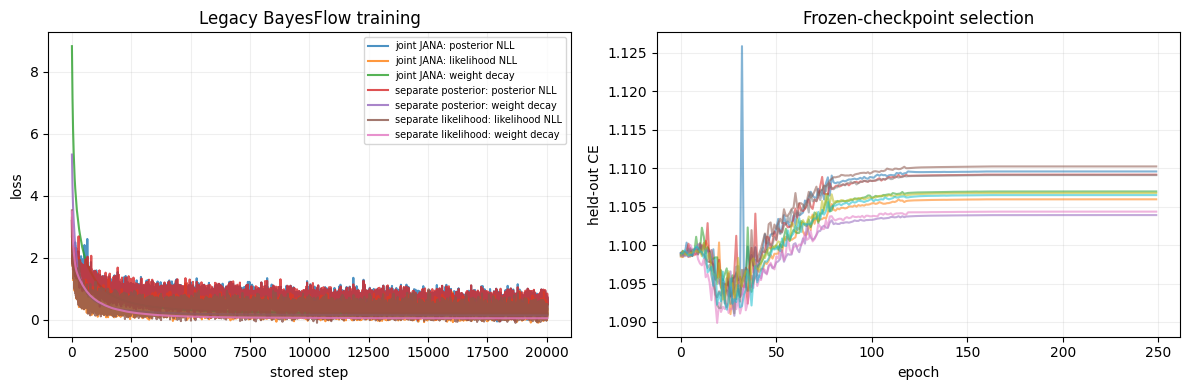

In [23]:
# Training histories: legacy NLLs and the ten CE members.
history_stems = {
    "joint JANA": ARTIFACT_ROOT / "joint_jana_history",
    "separate posterior": ARTIFACT_ROOT / "separate_posterior_history",
    "separate likelihood": ARTIFACT_ROOT / "separate_likelihood_history",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, stem in history_stems.items():
    csv_path = stem.with_suffix(".csv")
    json_path = stem.with_suffix(".json")

    if csv_path.is_file():
        frame = pd.read_csv(csv_path)
        loss_columns = [
            column for column in frame.columns
            if "loss" in column.lower() and "val" not in column.lower()
        ]
        curves = [(column, frame[column].to_numpy()) for column in loss_columns]
        print(label, "CSV columns:", list(frame.columns))

    elif json_path.is_file():
        payload = json.loads(json_path.read_text())
        train_losses = np.asarray(payload["train_losses"], dtype=np.float64)
        if train_losses.ndim == 1:
            train_losses = train_losses[:, None]
        if label == "joint JANA":
            names = ["posterior NLL", "likelihood NLL", "weight decay"]
        elif label == "separate posterior":
            names = ["posterior NLL", "weight decay"]
        else:
            names = ["likelihood NLL", "weight decay"]
        if len(names) != train_losses.shape[1]:
            names = [f"loss component {index + 1}" for index in range(train_losses.shape[1])]
        curves = [(name, train_losses[:, index]) for index, name in enumerate(names)]
        print(label, "JSON shape:", train_losses.shape)

    else:
        raise FileNotFoundError(f"No CSV or JSON history artifact found for {stem}")

    for curve_name, values in curves:
        axes[0].plot(values, alpha=0.8, label=f"{label}: {curve_name}")

for member, pack in enumerate(classifier):
    axes[1].plot(
        pack["history"]["validation_ce"], alpha=0.55,
        label=f"member {member + 1}",
    )

axes[0].set(title="Legacy BayesFlow training", xlabel="stored step", ylabel="loss")
axes[1].set(title="Frozen-checkpoint selection", xlabel="epoch", ylabel="held-out CE")
for axis in axes:
    axis.grid(alpha=0.2)
axes[0].legend(fontsize=7)
if len(classifier) <= 4:
    axes[1].legend(fontsize=7)
fig.tight_layout()
fig.savefig(ARTIFACT_ROOT / "training_histories.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. How to interpret the run

This experiment separates three possible explanations for the earlier discrepancy.

- If **original JANA now recovers both crescents**, the poor result in `Exercise_9b_SBIBM_TwoMoons.ipynb` was not evidence against the published JANA result. It arose from changing the simulator and replacing the historical architecture/training campaign.
- If original JANA works but the **matched separate flows** do not, the remaining issue is optimization variability or the separation of the two optimizers, not flow capacity.
- If the matched separate flows are imperfect but **CE improves both posterior and likelihood routes**, the classifier is doing the intended residual correction.
- If CE improves one route but worsens the other, inspect the two normalization audits and the corrected bridge variance. That pattern identifies which conditional reference or density ratio is failing.
- Agreement between the corrected posterior and likelihood routes is an internal consistency test, not an independent truth test. The analytical posterior and paper-matched MMD remain the external benchmark.

For a literal ten-repetition reproduction of the paper's reliability study, rerun the notebook with `SEED = 1, …, 10` into separate artifact directories. The default run is seed 1, the repetition displayed in the main paper.

In [24]:
# Final immutable run manifest.
manifest = {
    "status": "complete",
    "profile": PROFILE,
    "seed": SEED,
    "simulation_budget": SIMULATION_BUDGET,
    "legacy_metadata": metadata,
    "classifier_config": classifier_config,
    "diagnostics": diagnostics.to_dict(orient="records"),
    "inference_diagnostics": (
        inference_diagnostics.to_dict(orient="records")
    ),
    "paper_multiscale_mmd": metric_table.to_dict(orient="records"),
    "result_path": str(result_path),
    "figure_path": str(figure_path),
    "extra_figure_paths": EXTRA_FIGURE_PATHS,
    "expanded_metric_path": str(expanded_metric_path),
    "sliced_wasserstein_path": str(sliced_wasserstein_path),
    "interval_path": str(interval_path),
    "ensemble_diagnostics_path": str(ensemble_diagnostics_path),
}
manifest_path = ARTIFACT_ROOT / "run_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, sort_keys=True)
)
print("Run complete:", manifest_path)

Run complete: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA_TwoMoons/seed_01/run_manifest.json
